In [1]:
""" Log
12/27/25 ---- Implemented AAA-greedy for Hubbard dimer of different sce/wce order.
Using the wce data up to t=1 and sce dat up to t=0.05 to construct the interpolation.
5/9/26 ---- Test copy using AAA_holo_interp, which rejects poles with real part in [0.1, 0.6].
"""

' Log\n12/27/25 ---- Implemented AAA-greedy for Hubbard dimer of different sce/wce order.\nUsing the wce data up to t=1 and sce dat up to t=0.05 to construct the interpolation.\n5/9/26 ---- Test copy using AAA_holo_interp, which rejects poles with real part in [0.1, 0.6].\n'

In [2]:
### Using AAA to interpolate G(t, U=1.0, iw_n).
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import analytic_solution as AS
import diff_G as diff
import utilities as ut
from adapol import anacont
from _bary_rational import AAA_holo_interp
import greedy_interpolation as greedy

In [3]:
beta = 10.0
Ntau = 401
Ns = 2
Nw = 4*int(beta)
Mat_fre = (2*np.linspace(0, Nw-1, Nw)+1)*np.pi/beta

wn = np.append(-np.flip(Mat_fre),Mat_fre)   # w_n = (2n+1)*pi/beta

In [4]:
eta = 0
Nt = 501
T = 20
t_values_ED = np.linspace(0, T, Nt) +1j*eta
wce_order = 12
test_order = wce_order + 1
Gij_iwn_exact = np.zeros((len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_exact_real = np.zeros((len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_wce = np.zeros((test_order, len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_sce = np.zeros((test_order, len(t_values_ED), wn.size, Ns, Ns), dtype ='complex')
U = 4.0
for u in range(t_values_ED.size):
    # if np.abs(t_values_ED[u]) < 1e-10:
    #     Gij_iwn_exact[u] = AS.G_analytic(0, wn, U, beta)
    #     Gij_iwn_exact_real[u] = AS.G_analytic(0, wn, U, beta)
    # else:
    #     Gij_iwn_exact[u] = 1/t_values_ED[u]*AS.G_analytic_old(1/t_values_ED[u], wn/t_values_ED[u])
    #     Gij_iwn_exact_real[u] = 1/t_values_ED[u]*AS.G_analytic_old(1/t_values_ED[u], wn/t_values_ED[u])
    Gij_iwn_exact[u] = AS.G_analytic(t_values_ED[u], wn, U, beta)
    Gij_iwn_exact_real[u] = AS.G_analytic(t_values_ED[u], wn, U, beta)
    for order in range(test_order):
        Gij_iwn_wce[order, u] = diff.Gij_wce_series(order, t_values_ED[u],  U , wn)
        Gij_iwn_sce[order, u] = diff.Gij_sce_series(order, t_values_ED[u],  U , wn, beta)

/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/t_interpolation/../diff_G.py:32: RuntimeWarning: divide by zero encountered in divide
  G2[:,0,0] =  0.5*((-b1+6*t)/(64*(b1-2*t)**2*t**2)-(b2+6*t)/(64*(b2+2*t)**2*t**2)+1/(64*(b3-2*t)*t**2)+ 1/(64*(b4+2*t)*t**2))
/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/t_interpolation/../diff_G.py:32: RuntimeWarning: invalid value encountered in divide
  G2[:,0,0] =  0.5*((-b1+6*t)/(64*(b1-2*t)**2*t**2)-(b2+6*t)/(64*(b2+2*t)**2*t**2)+1/(64*(b3-2*t)*t**2)+ 1/(64*(b4+2*t)*t**2))
/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_body_interpolation/hubbard_dimer/t_interpolation/../diff_G.py:33: RuntimeWarning: divide by zero encountered in divide
  G2[:,0,1] =  0.5*((b1-6*t)/(64*(b1-2*t)**2*t**2)-(b2+6*t)/(64*(b2+2*t)**2*t**2)+1/(64*(b3-2*t)*t**2)- 1/(64*(b4+2*t)*t**2))
/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/Many_

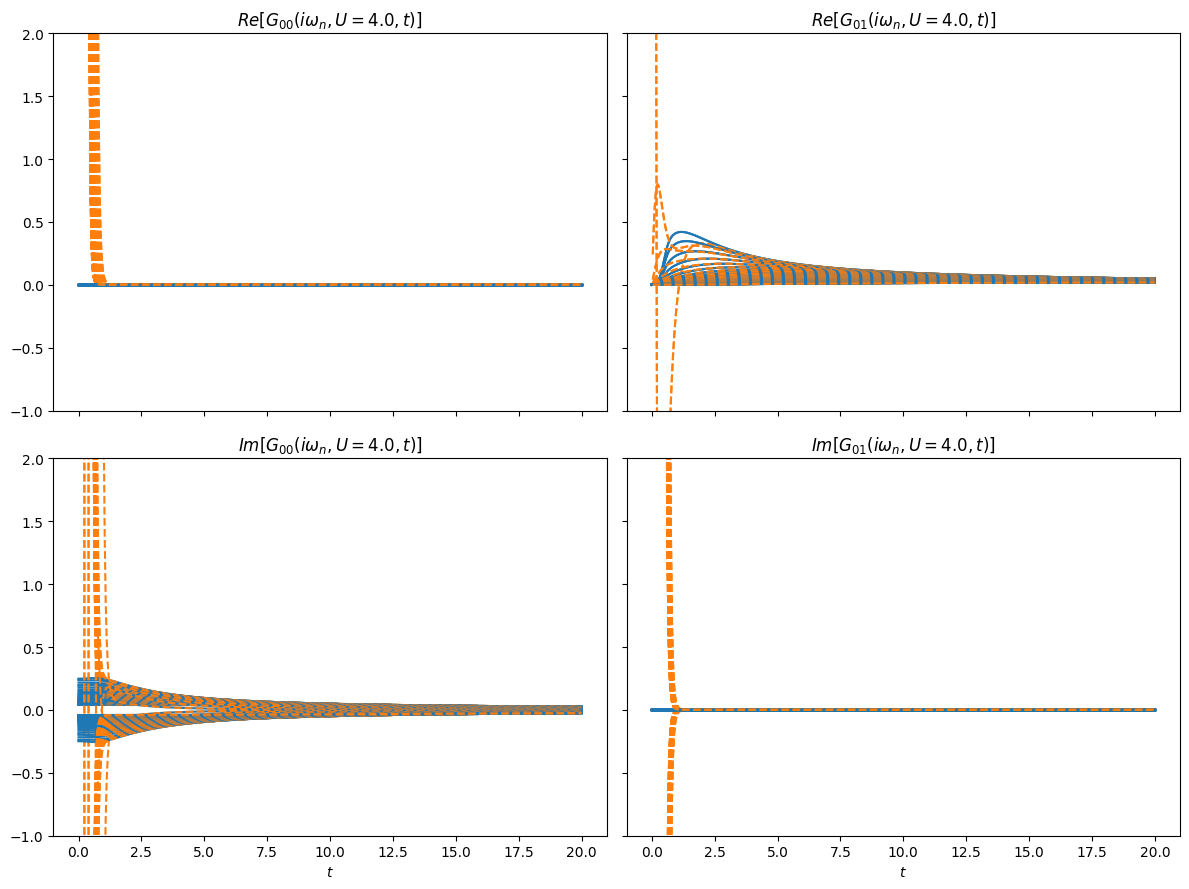

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
for i in range(wn.size):
    ax11.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].real, 'C0')
    ax11.plot(t_values_ED.real, Gij_iwn_wce[-1,:, i, 0, 0 ].real, 'C1--')
ax11.set_title(r'$Re[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))
ax11.set_ylim([-1,2])
# (1,2) — like your figure(2)
for i in range(wn.size):
    ax12.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax12.plot(t_values_ED.real, Gij_iwn_wce[2,:, i, 0,1 ].real, 'C1--')
ax12.set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax21.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C0')
    ax21.plot(t_values_ED.real, Gij_iwn_wce[-1,:, i, 0, 0 ].imag, 'C1--')
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,2) — like your figure(4)
for i in range(wn.size):
    ax22.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0, 1 ].imag, 'C0')
    ax22.plot(t_values_ED.real, Gij_iwn_wce[-1, :, i, 0, 1 ].imag, 'C1--')
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

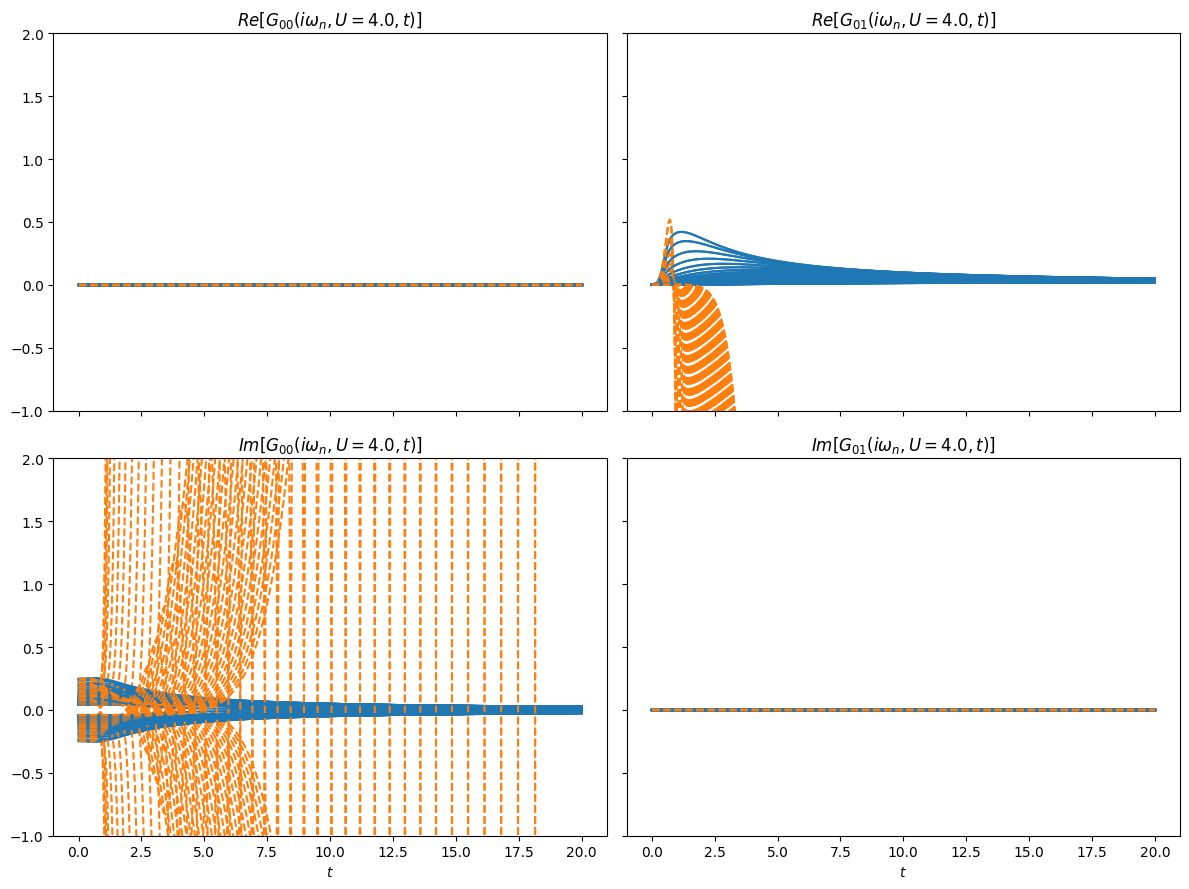

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
for i in range(wn.size):
    ax11.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].real, 'C0')
    ax11.plot(t_values_ED.real, Gij_iwn_sce[-1,:, i, 0, 0 ].real, 'C1--')
ax11.set_title(r'$Re[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))
ax11.set_ylim([-1,2])
# (1,2) — like your figure(2)
for i in range(wn.size):
    ax12.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax12.plot(t_values_ED.real, Gij_iwn_sce[-1,:, i, 0,1 ].real, 'C1--')
ax12.set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax21.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C0')
    ax21.plot(t_values_ED.real, Gij_iwn_sce[-1,:, i, 0, 0 ].imag, 'C1--')
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%(U))

# (2,2) — like your figure(4)
for i in range(wn.size):
    ax22.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0, 1 ].imag, 'C0')
    ax22.plot(t_values_ED.real, Gij_iwn_sce[-1, :, i, 0, 1 ].imag, 'C1--')
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[G_{01}(i\omega_n,U=%.1f, t)]$'%(U))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

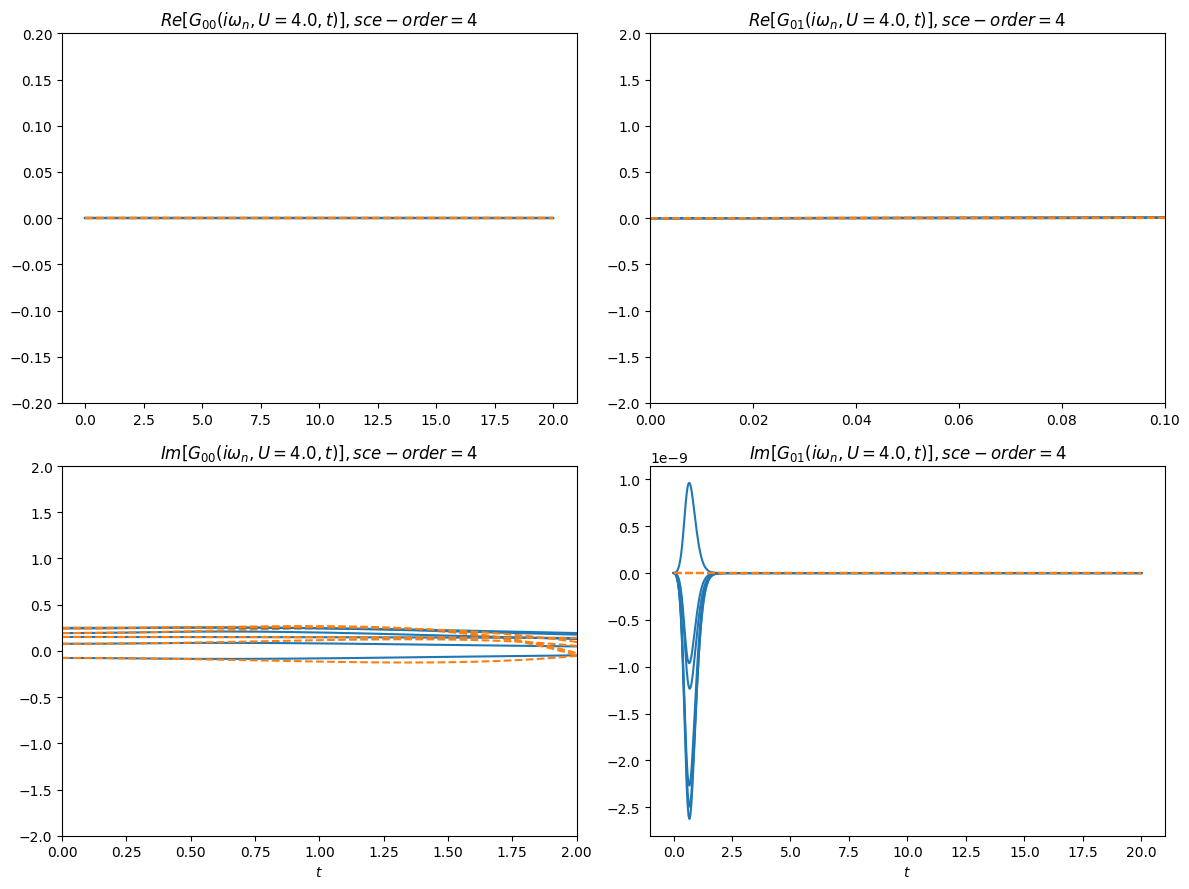

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes
wn_id=[Nw, Nw-1, Nw-2, Nw-3, Nw-4, Nw-10]
sce_order = 4
# (1,1) — like your figure(1)
for i in wn_id:
    ax11.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].real, 'C0')
    ax11.plot(t_values_ED.real, Gij_iwn_sce[sce_order,:, i, 0, 0 ].real, 'C1--')
ax11.set_title(r'$Re[G_{00}(i\omega_n,U=%.1f, t)], sce-order=%d$'%(U, sce_order))
ax11.set_ylim([-0.2,0.2])
# (1,2) — like your figure(2)
for i in wn_id:
    ax12.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0,1 ].real, 'C0')
    ax12.plot(t_values_ED.real, Gij_iwn_sce[sce_order,:, i, 0,1 ].real, 'C1--')
ax12.set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)], sce-order=%d$'%(U, sce_order))
ax12.set_ylim([-2,2])
ax12.set_xlim([0,0.1])
# (2,1) — like your figure(3)
for i in wn_id:
    ax21.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0, 0 ].imag, 'C0')
    ax21.plot(t_values_ED.real, Gij_iwn_sce[sce_order,:, i, 0, 0 ].imag, 'C1--')
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)], sce-order=%d$'%(U, sce_order))
ax21.set_ylim([-2,2])
ax21.set_xlim([0,2])

# (2,2) — like your figure(4)
for i in wn_id:
    ax22.plot(t_values_ED.real, Gij_iwn_exact[:, i, 0, 1 ].imag, 'C0')
    ax22.plot(t_values_ED.real, Gij_iwn_sce[sce_order, :, i, 0, 1 ].imag, 'C1--')
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[G_{01}(i\omega_n,U=%.1f, t)], sce-order=%d$'%(U, sce_order))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()

t_values that wce/sce works for G00: (1.8+0j) (0.52+0j)
t_values that wce/sce works for G01: (1.72+0j) (0.36+0j)


/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/yzhu4/Desktop/projects/rational_interpolation_hubbard/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


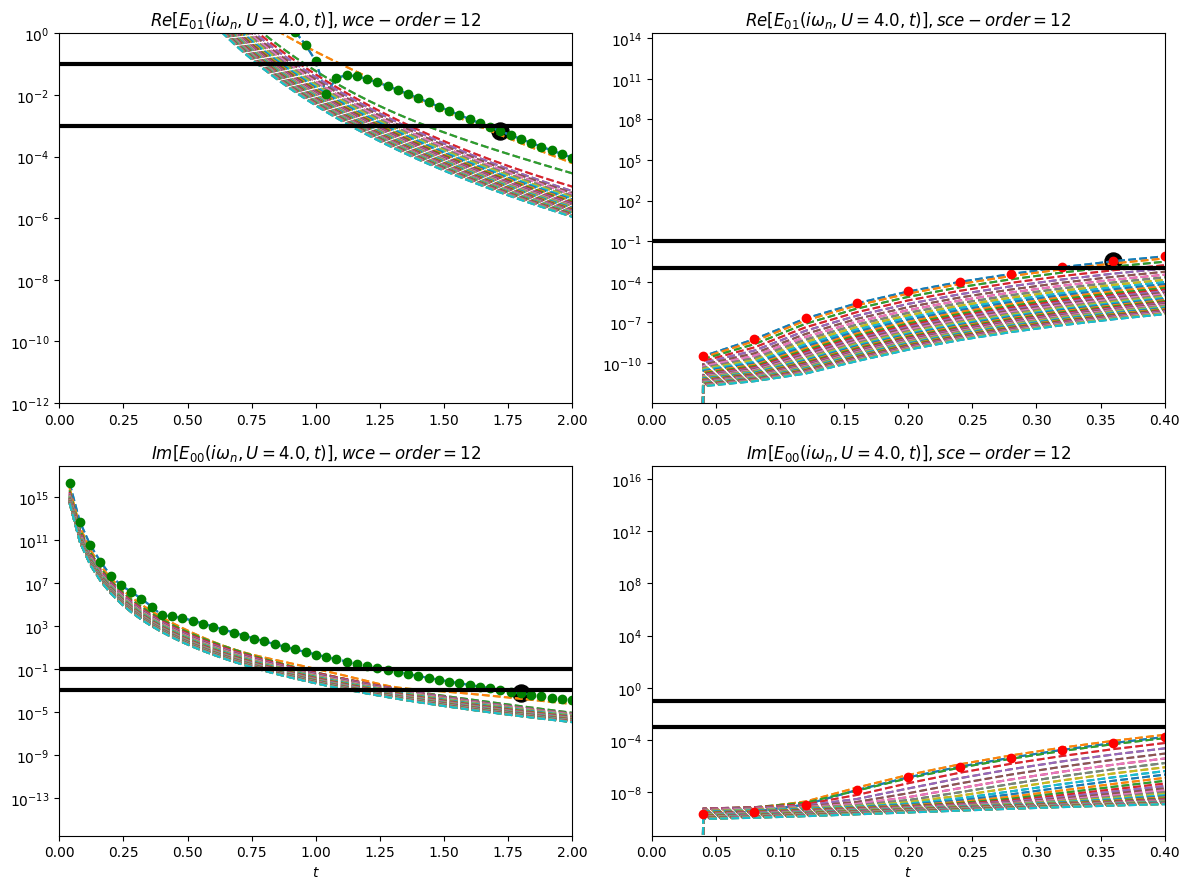

In [8]:
err_bar = 1e-3
err_bar2 = 1e-1
wn_id = Nw
interp_order = 12
wce00_err = np.abs(Gij_iwn_exact[:, wn_id, 0,0]-Gij_iwn_wce[interp_order, :, wn_id, 0,0]) 
wce01_err = np.abs(Gij_iwn_exact[:, wn_id, 0,1]-Gij_iwn_wce[interp_order, :, wn_id, 0,1])
sce00_err = np.abs(Gij_iwn_exact[:, wn_id, 0,0]-Gij_iwn_sce[interp_order, :, wn_id, 0,0]) 
sce01_err = np.abs(Gij_iwn_exact[:, wn_id, 0,1]-Gij_iwn_sce[interp_order, :, wn_id, 0,1])

idx = np.where(wce00_err < err_bar)[0]
wce00_err_idx = idx[0]+1
idx = np.where(wce01_err < err_bar)[0]
if len(idx)==0:
    wce01_err_idx = 0
else:
    wce01_err_idx = idx[0]+1
idx = np.where(sce00_err > err_bar)[0]
sce00_err_idx = idx[0]+1
idx = np.where(sce01_err > err_bar)[0]
sce01_err_idx = idx[0]+1
print("t_values that wce/sce works for G00:", t_values_ED[wce00_err_idx], t_values_ED[sce00_err_idx])
print("t_values that wce/sce works for G01:", t_values_ED[wce01_err_idx], t_values_ED[sce01_err_idx] )


    
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

# (1,2) — like your figure(2)
for i in range(wn.size):
    ax11.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,1]-Gij_iwn_wce[interp_order, :, i, 0,1]), '--')
ax11.semilogy(t_values_ED.real, wce01_err, 'go', linewidth = 3)
ax11.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax11.semilogy(t_values_ED.real, err_bar2+0*t_values_ED, 'k', linewidth = 3)
ax11.scatter(t_values_ED[wce01_err_idx].real, wce01_err[wce01_err_idx], color='k', s=150)
ax11.set_xlim([0, 2])
ax11.set_ylim([1e-12, 1])
ax11.set_title(r'$Re[E_{01}(i\omega_n,U=%.1f, t)],wce-order= %d$'%(U, interp_order))

# (1,2) — like your figure(2)
for i in range(wn.size):
    ax12.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,1]-Gij_iwn_sce[interp_order, :, i, 0,1]), '--')
ax12.semilogy(t_values_ED.real, sce01_err, 'ro', linewidth = 3)
ax12.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax12.semilogy(t_values_ED.real, err_bar2+0*t_values_ED, 'k', linewidth = 3)
ax12.scatter(t_values_ED[sce01_err_idx].real, sce01_err[sce01_err_idx], color='k', s=150)
ax12.set_xlim([0, 0.4])
ax12.set_title(r'$Re[E_{01}(i\omega_n,U=%.1f, t)],sce-order=%d$'%(U, interp_order))
# ax12.set_ylim(1e-10,1)

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax21.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,0]-Gij_iwn_wce[interp_order,:, i, 0,0]), '--')
ax21.semilogy(t_values_ED.real, wce00_err, 'go', linewidth = 3)
ax21.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax21.semilogy(t_values_ED.real, err_bar2+0*t_values_ED, 'k', linewidth = 3)
ax21.scatter(t_values_ED[wce00_err_idx].real, wce00_err[wce00_err_idx], color='k', s=150)
ax21.set_xlim([0, 2])
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[E_{00}(i\omega_n,U=%.1f, t)],wce-order=%d$'%(U, interp_order))

# (2,1) — like your figure(3)
for i in range(wn.size):
    ax22.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, i, 0,0]-Gij_iwn_sce[interp_order,:, i, 0,0]), '--')
ax22.semilogy(t_values_ED.real, sce00_err, 'ro', linewidth = 3)
ax22.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax22.semilogy(t_values_ED.real, err_bar2+0*t_values_ED, 'k', linewidth = 3)
ax22.scatter(t_values_ED[sce00_err_idx].real, sce00_err[sce00_err_idx], color='k', s=150)
ax22.set_xlabel(r'$t$')
ax22.set_xlim([0, 0.4])
ax22.set_title(r'$Im[E_{00}(i\omega_n,U=%.1f, t)],sce-order=%d$'%(U, interp_order))

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')

fig.tight_layout()
plt.show()




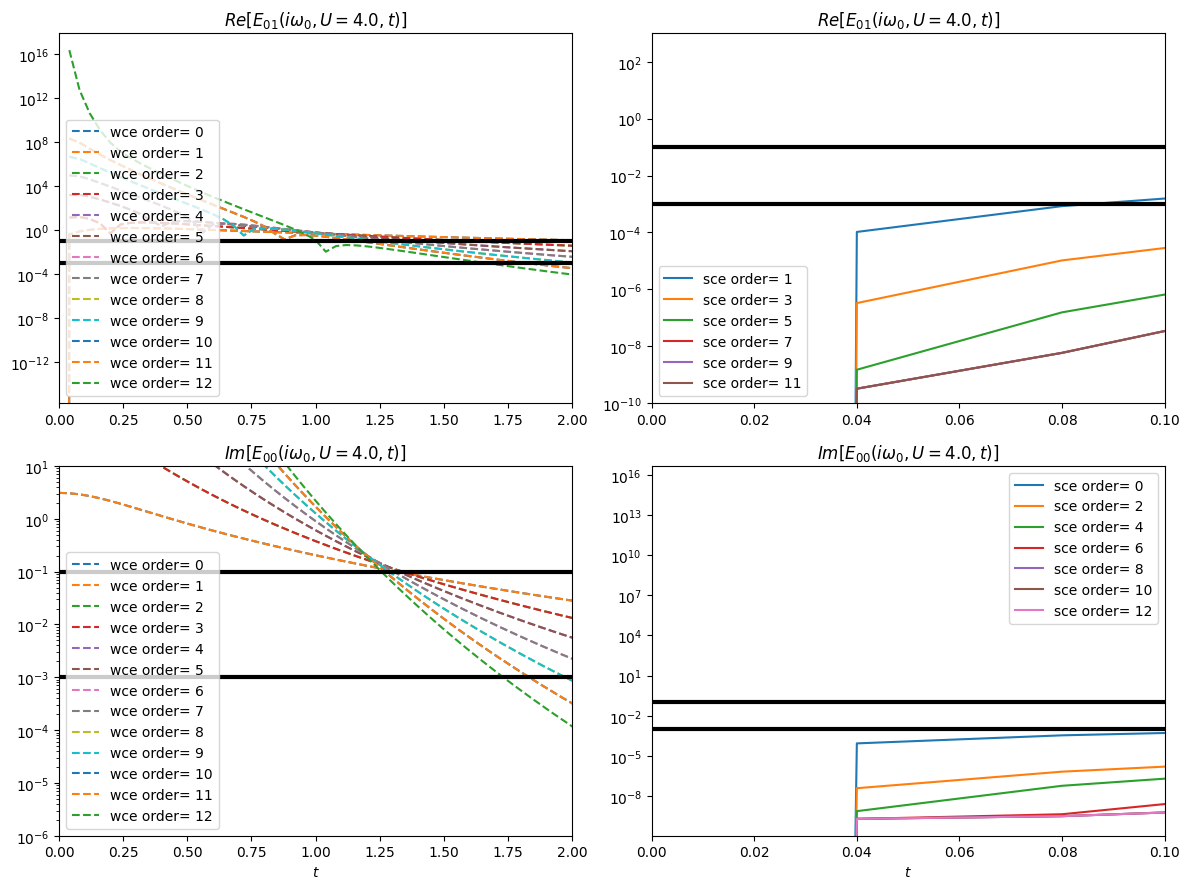

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
# (1,2) — like your figure(2)
for i in range(test_order):
    ax11.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,1]-Gij_iwn_wce[i, :, Nw, 0,1]), '--', label = 'wce order= %d'%i)
ax11.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax11.semilogy(t_values_ED.real, err_bar2+0*t_values_ED, 'k', linewidth = 3)
ax11.set_title(r'$Re[E_{01}(i\omega_0,U=%.1f, t)]$'%U)
ax11.set_xlim([0, 2])
ax11.legend()

# (1,2) — like your figure(2)
for i in range(test_order):
    if np.mod(i,2)==1:
        ax12.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,1]-Gij_iwn_sce[i, :, Nw, 0,1]), label = 'sce order= %d'%i)
ax12.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax12.semilogy(t_values_ED.real, err_bar2+0*t_values_ED, 'k', linewidth = 3)
ax12.set_title(r'$Re[E_{01}(i\omega_0,U=%.1f, t)]$'%U)
ax12.set_xlim([0, 0.1])
ax12.set_ylim([1e-10, 1000])
ax12.legend()

# (2,1) — like your figure(3)
for i in range(test_order):
    ax21.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,0]-Gij_iwn_wce[i,:, Nw, 0,0]), '--', label = 'wce order= %d'%i)
ax21.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax21.semilogy(t_values_ED.real, err_bar2+0*t_values_ED, 'k', linewidth = 3)
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[E_{00}(i\omega_0,U=%.1f, t)]$'%U)
ax21.set_xlim([0, 2])
ax21.legend()
ax21.set_ylim([1e-6, 10])
for i in range(test_order):
        if np.mod(i,2)==0:
            ax22.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,0]-Gij_iwn_sce[i,:, Nw, 0,0]), label = 'sce order= %d'%i)
ax22.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax22.semilogy(t_values_ED.real, err_bar2+0*t_values_ED, 'k', linewidth = 3)
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[E_{00}(i\omega_0,U=%.1f, t)]$'%U)
ax22.set_xlim([0, 0.1])
ax22.legend()

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')
    

fig.tight_layout()
plt.show()

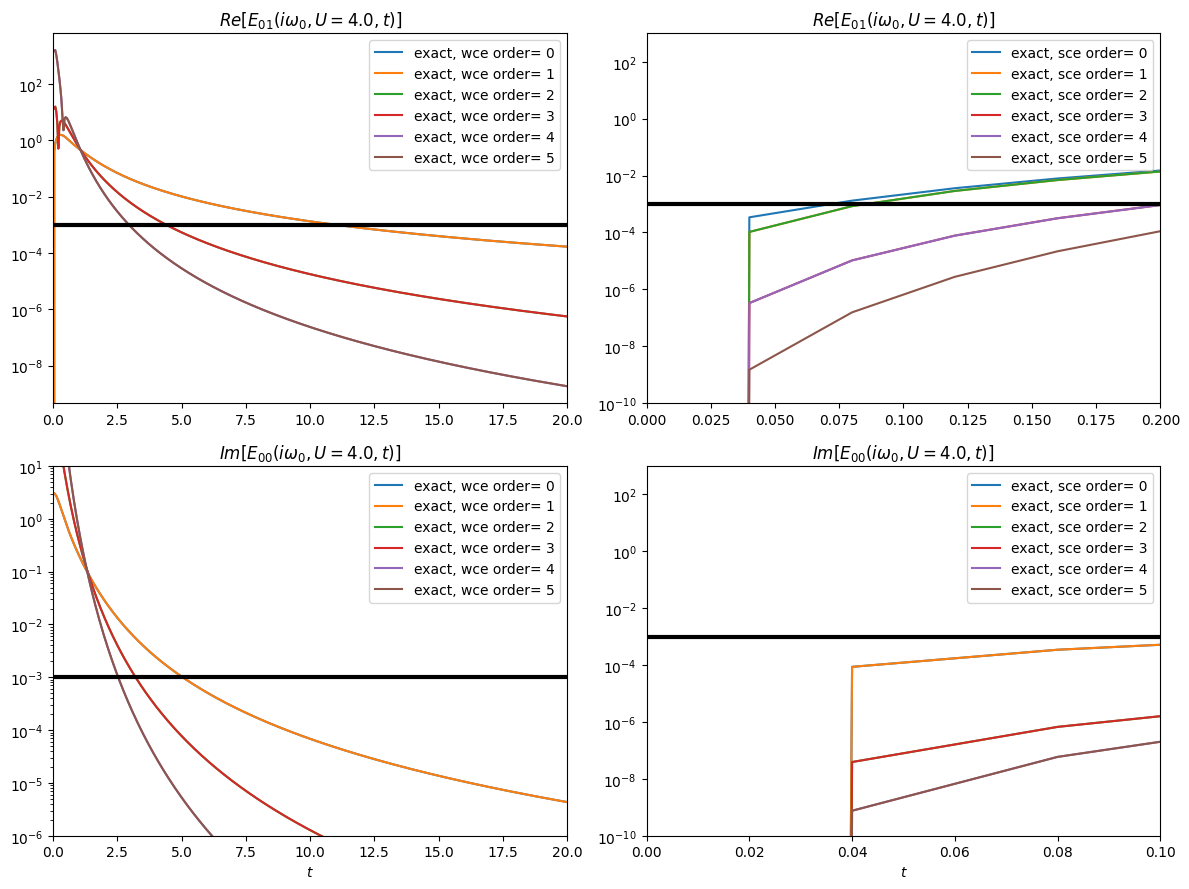

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False, sharey=False)
(ax11, ax12), (ax21, ax22) = axes

# (1,1) — like your figure(1)
# (1,2) — like your figure(2)
order_up = 6
for i in range(order_up):
    # ax11.semilogy(t_values_ED.real, np.abs(Gij_iwn_wce[order_up, :, Nw, 0,1]-Gij_iwn_wce[i, :, Nw, 0,1]), '--', label = 'wce order= %d-%d'%(order_up,i))
    ax11.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,1]-Gij_iwn_wce[i, :, Nw, 0,1]), label = 'exact, wce order= %d'%i)
ax11.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax11.set_title(r'$Re[E_{01}(i\omega_0,U=%.1f, t)]$'%U)
ax11.set_xlim([0, T])
ax11.legend()

# (1,2) — like your figure(2)
for i in range(order_up):
    # ax12.semilogy(t_values_ED.real, np.abs(Gij_iwn_sce[order_up, :, Nw, 0,1]-Gij_iwn_sce[i, :, Nw, 0,1]), '--', label = 'sce order= %d-%d'%(order_up,i))
    ax12.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,1]-Gij_iwn_sce[i, :, Nw, 0,1]), label = 'exact, sce order= %d'%i)
ax12.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax12.set_title(r'$Re[E_{01}(i\omega_0,U=%.1f, t)]$'%U)
ax12.set_xlim([0, 0.2])
ax12.set_ylim([1e-10, 1000])
ax12.legend()

# (2,1) — like your figure(3)
for i in range(order_up):
    # ax21.semilogy(t_values_ED.real, np.abs(Gij_iwn_wce[order_up,:, Nw, 0,0]-Gij_iwn_wce[i,:, Nw, 0,0]), '--', label = 'wce order= %d-%d'%(order_up,i))
    ax21.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,0]-Gij_iwn_wce[i, :, Nw, 0,0]), label = 'exact, wce order= %d'%i)
ax21.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax21.set_xlabel(r'$t$')
ax21.set_title(r'$Im[E_{00}(i\omega_0,U=%.1f, t)]$'%U)
ax21.set_xlim([0, T])
ax21.legend()
ax21.set_ylim([1e-6, 10])
for i in range(order_up):
    # ax22.semilogy(t_values_ED.real, np.abs(Gij_iwn_sce[order_up,:, Nw, 0,0]-Gij_iwn_sce[i,:, Nw, 0,0]), '--',label = 'sce order= %d-%d'%(order_up,i))
    ax22.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact[:, Nw, 0,0]-Gij_iwn_sce[i, :, Nw, 0,0]), label = 'exact, sce order= %d'%i)
ax22.semilogy(t_values_ED.real, err_bar+0*t_values_ED, 'k', linewidth = 3)
ax22.set_xlabel(r'$t$')
ax22.set_title(r'$Im[E_{00}(i\omega_0,U=%.1f, t)]$'%U)
ax22.set_ylim([1e-10, 1000])
ax22.set_xlim([0, 0.1])
ax22.legend()

# Optional: remove duplicate y-labels on the right column
for ax in (ax12, ax22):
    ax.set_ylabel('')
    

fig.tight_layout()
plt.show()

The wce time window is: (1.72, 20)
The sce time window is: (0, 0.36)
[0.         0.00176471 0.00352941 0.00529412 0.00705882 0.00882353
 0.01058824 0.01235294 0.01411765 0.01588235 0.01764706 0.01941176
 0.02117647 0.02294118 0.02470588 0.02647059 0.02823529 0.03
 0.03176471 0.03352941 0.03529412 0.03705882 0.03882353 0.04058824
 0.04235294 0.04411765 0.04588235 0.04764706 0.04941176 0.05117647
 0.05294118 0.05470588 0.05647059 0.05823529 0.06       0.06176471
 0.06352941 0.06529412 0.06705882 0.06882353 0.07058824 0.07235294
 0.07411765 0.07588235 0.07764706 0.07941176 0.08117647 0.08294118
 0.08470588 0.08647059 0.08823529 0.09       0.09176471 0.09352941
 0.09529412 0.09705882 0.09882353 0.10058824 0.10235294 0.10411765
 0.10588235 0.10764706 0.10941176 0.11117647 0.11294118 0.11470588
 0.11647059 0.11823529 0.12       0.12176471 0.12352941 0.12529412
 0.12705882 0.12882353 0.13058824 0.13235294 0.13411765 0.13588235
 0.13764706 0.13941176 0.14117647 0.14294118 0.14470588 0.14647059

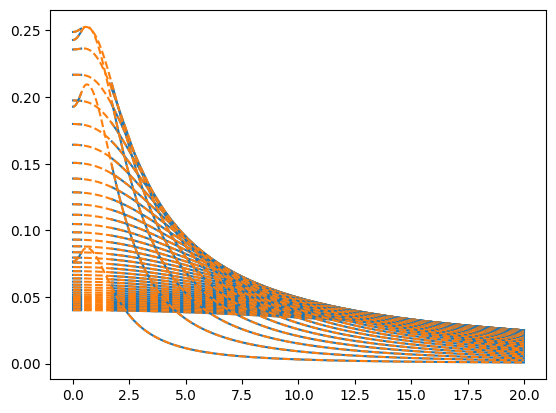

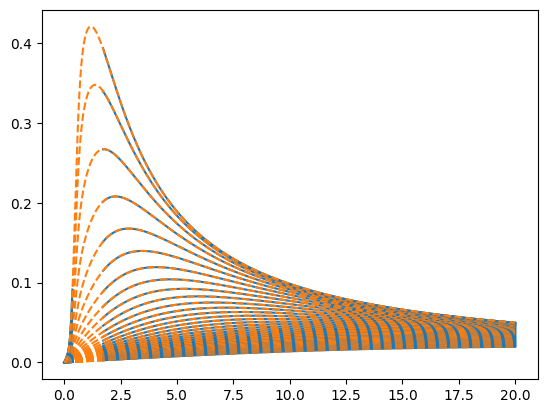

In [11]:
### Constructing the interpolation data 
Nt_wce = 501 
T_wce = 1.72
print("The wce time window is:", (T_wce, T))
t_wce = np.linspace(T_wce, T, Nt_wce)

G_wce = np.zeros((len(t_wce), wn.size, Ns, Ns), dtype ='complex')
for i in range(len(t_wce)):
    G_wce[i] = diff.Gij_wce_series(interp_order, t_wce[i],  U , wn)

Nt_sce = 205
T_sce = 0.36
print("The sce time window is:", (0, T_sce))
t_sce = np.linspace(0, T_sce, Nt_sce)

G_sce = np.zeros((len(t_sce), wn.size, Ns, Ns), dtype ='complex')
for i in range(len(t_sce)):
    G_sce[i] = diff.Gij_sce_series(interp_order, t_sce[i],  U , wn, beta)
print(t_sce)
t_app = np.concatenate([t_sce, t_wce], axis=0)
G_app = np.concatenate([G_sce, G_wce], axis=0)
print(t_app.shape)
print(G_app.shape)

plt.figure(1)
for n in range(Nw):
    plt.plot(t_sce, G_sce[:, n, 0, 0].imag ,'C0')
    plt.plot(t_wce, G_wce[:, n, 0, 0].imag, 'C0')
    plt.plot(t_values_ED.real, Gij_iwn_exact[:, n, 0,0].imag, 'C1--')

plt.figure(2)
for n in range(Nw):
    plt.plot(t_sce, G_sce[:, n, 0, 1].real ,'C0')
    plt.plot(t_wce, G_wce[:, n, 0, 1].real, 'C0')
    plt.plot(t_values_ED.real, Gij_iwn_exact[:, n, 0,1].real, 'C1--')

In [12]:
### AAA interpolation 
err_bar1 = 1e-3
G01_interp = np.zeros((t_values_ED.size, wn.size), dtype = complex)
G00_interp = np.zeros((t_values_ED.size, wn.size), dtype = complex)

for n in range(wn.size):
    print("n=", n)
    # G00_interp_temp = greedy.G_interp_v2(G_sce[:, n, 0, 0].imag, t_sce, G_wce[:, n, 0, 0].imag, t_wce, t_values_ED.real,  err=err_bar1, max_terms= 40)
    # G00_interp[:, n] = 1j*G00_interp_temp
    # G01_interp[:, n] = greedy.G_interp_v2(G_sce[:, n, 0, 1].real, t_sce, G_wce[:, n, 0,1].real, t_wce, t_values_ED.real,  err=err_bar1, max_terms= 40)
    # r00 = AAA_holo_interp(t_app, G_app[:, n, 0,0].imag, rtol=err_bar1, max_terms= 40)
    # G00_interp[:, n] = 1j*r00(t_values_ED.real)
    # r01 = AAA_holo_interp(t_app, G_app[:, n, 0,1].real, rtol=err_bar1, max_terms= 40)
    # G01_interp[:, n] = r01(t_values_ED.real)
    r00 = AAA_holo_interp(t_app, G_app[:, n, 0,0], rtol=err_bar1, max_terms= 10, pole_real_window=(T_sce, T_wce), perturbation_magnitude= 1e-4, max_trials=100)
    G00_interp[:, n] = r00(t_values_ED.real)
    r01 = AAA_holo_interp(t_app, G_app[:, n, 0,1], rtol=err_bar1, max_terms= 10, pole_real_window=(T_sce, T_wce), perturbation_magnitude= 1e-4, max_trials= 100)
    G01_interp[:, n] = r01(t_values_ED.real)

n= 0
AAA_holo_interp final max_error: 0.0022130902000954008
AAA_holo_interp perturbation_magnitude: 0.0001
AAA_holo_interp perturbation_trials: 1
AAA_holo_interp accepted a perturbed interpolation
n= 1
AAA_holo_interp final max_error: 0.0005725807250198925
AAA_holo_interp perturbation_magnitude: 0.0001
AAA_holo_interp perturbation_trials: 1
AAA_holo_interp accepted a perturbed interpolation
n= 2
AAA_holo_interp final max_error: 0.00525554563080424
AAA_holo_interp perturbation_magnitude: 0.0001
AAA_holo_interp perturbation_trials: 1
AAA_holo_interp accepted a perturbed interpolation
n= 3
AAA_holo_interp final max_error: 0.00042113894735568575
AAA_holo_interp perturbation_magnitude: 0.0001
AAA_holo_interp perturbation_trials: 1
AAA_holo_interp accepted a perturbed interpolation
n= 4
AAA_holo_interp final max_error: 0.003339384387567446
AAA_holo_interp perturbation_magnitude: 0.0001
AAA_holo_interp perturbation_trials: 2
AAA_holo_interp accepted a perturbed interpolation
n= 5
AAA_holo_int

n =  39


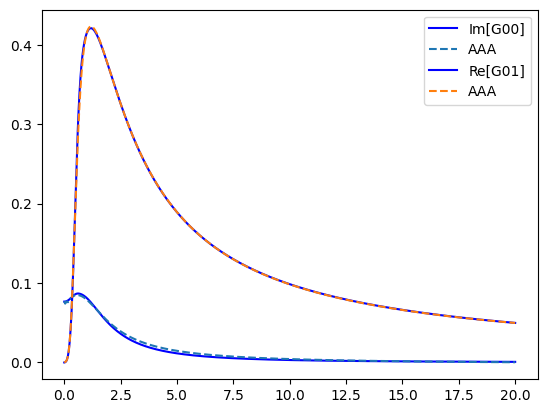

In [25]:
n = [Nw-1]
for i in n:
    print("n = ", i)
    plt.plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,0].imag, 'b', label = 'Im[G00]')
    plt.plot(t_values_ED.real, G00_interp[:, i].imag, 'C0--', label = 'AAA')
    plt.plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1].real, 'b', label = 'Re[G01]')
    plt.plot(t_values_ED.real, G01_interp[:, i].real, 'C1--', label = 'AAA')
    plt.legend()

frequency = 0.3141592653589793
frequency = -0.3141592653589793
frequency = -0.9424777960769379
frequency = -1.5707963267948966
frequency = -2.199114857512855


frequency = -2.827433388230814
frequency = -3.455751918948772
frequency = -4.084070449666731
frequency = -4.71238898038469
frequency = -5.340707511102648
frequency = -5.969026041820607
frequency = -9.1106186954104
frequency = -12.252211349000193
frequency = -15.393804002589984
frequency = -18.535396656179778




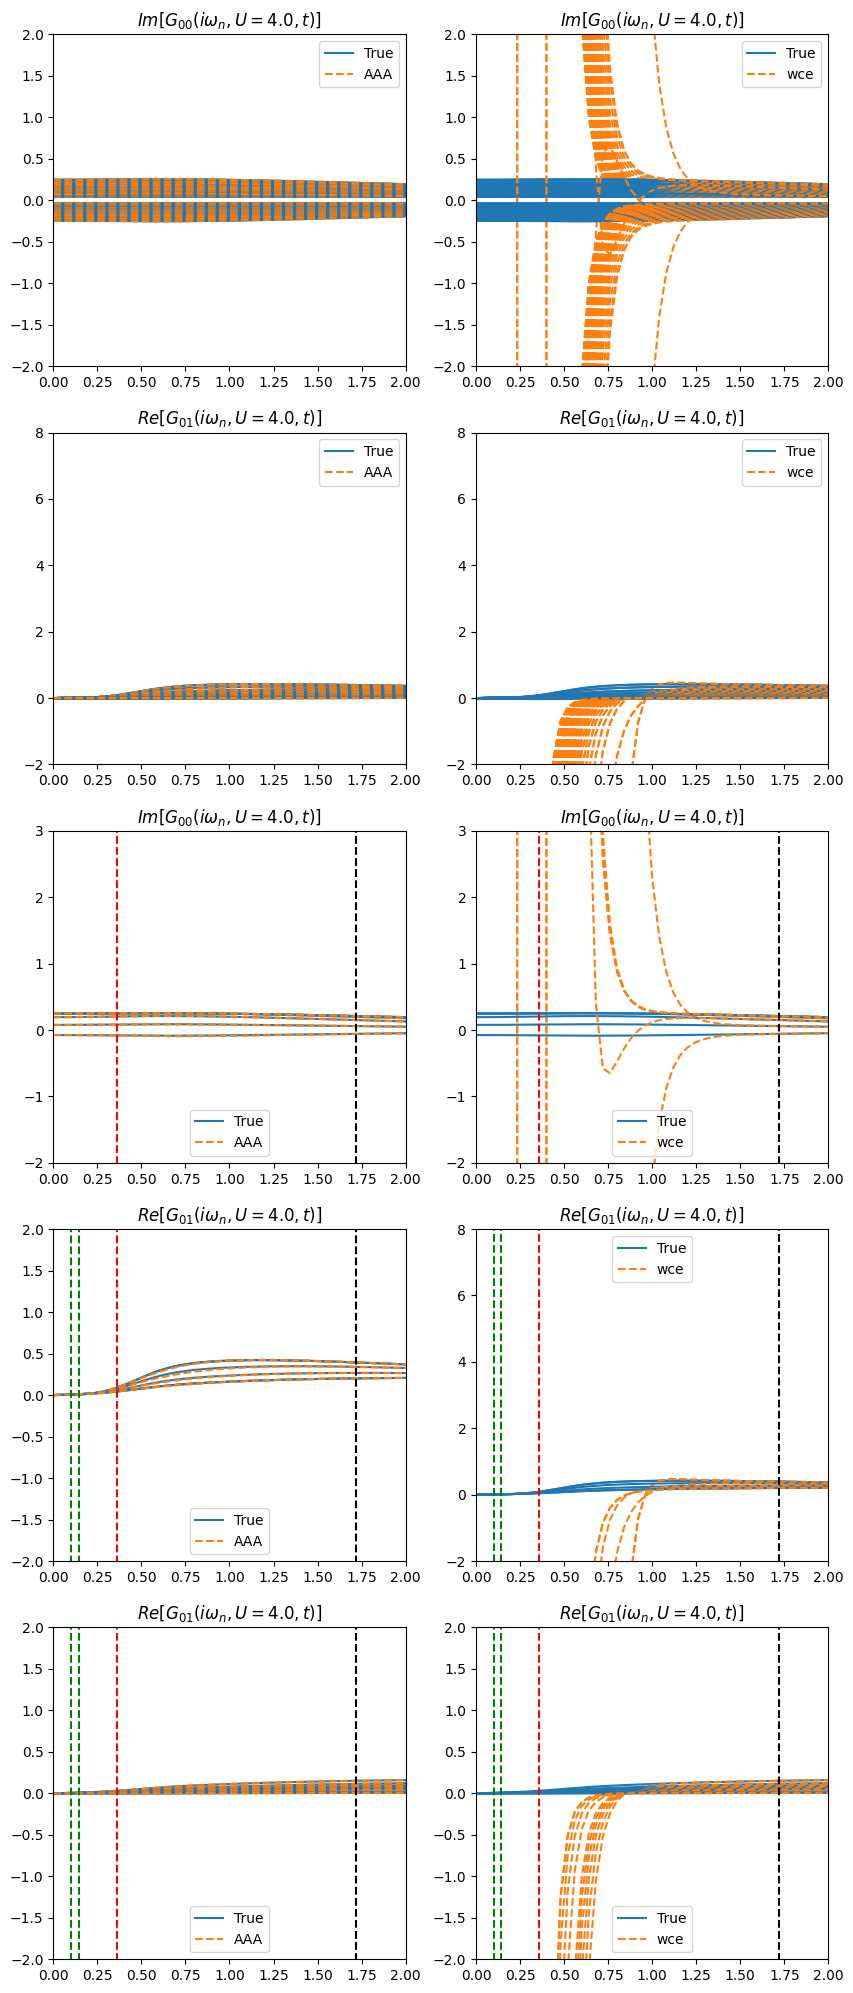

In [14]:
fig, ax = plt.subplots(5, 2, figsize=(10, 25), sharex=False, sharey=False)

for i in range(wn.size):
    ax[0,0].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,0].imag, 'C0')
    ax[0,0].plot(t_values_ED.real, G00_interp[:, i].imag, 'C1--')
ax[0,0].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,0].imag, 'C0', label = 'True')
ax[0,0].plot(t_values_ED.real, G00_interp[:, i].imag, 'C1--', label = 'AAA')
ax[0,0].set_ylim([-2,2])
ax[0,0].set_xlim([0,2])
ax[0,0].set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%U)
ax[0,0].legend()

for i in range(wn.size):
    ax[1,0].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0')
    ax[1,0].plot(t_values_ED.real, G01_interp[:, i].real, 'C1--')
ax[1,0].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0', label = 'True')
ax[1,0].plot(t_values_ED.real, G01_interp[:, i].real, 'C1--', label = 'AAA')
ax[1,0].set_ylim([-2,8])
ax[1,0].set_xlim([0,2])
ax[1,0].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[1,0].legend()

wn_id = [Nw, Nw-1, Nw-2, Nw-3, Nw-4]
for i in wn_id:
    print("frequency =", wn[i])
    ax[2,0].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,0 ].imag, 'C0')
    ax[2,0].plot(t_values_ED.real, G00_interp[:, i].imag, 'C1--')
ax[2,0].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,0 ].imag, 'C0', label = 'True')
ax[2,0].plot(t_values_ED.real, G00_interp[:, i].imag, 'C1--', label = 'AAA')
ax[2,0].plot(T_wce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'k--')
ax[2,0].plot(T_sce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'r--')
ax[2,0].set_ylim([-2,3])
ax[2,0].set_xlim([0,2])
ax[2,0].set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%U)
ax[2,0].legend()

for i in wn_id:
    ax[3,0].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0')
    ax[3,0].plot(t_values_ED.real, G01_interp[:, i].real, 'C1--')
ax[3,0].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0', label = 'True')
ax[3,0].plot(t_values_ED.real, G01_interp[:, i].real, 'C1--', label = 'AAA')
ax[3,0].plot(1/7+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'g--')
ax[3,0].plot(1/10+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'g--')
ax[3,0].plot(T_wce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'k--')
ax[3,0].plot(T_sce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'r--')
ax[3,0].set_ylim([-2,2])
ax[3,0].set_xlim([0,2])
ax[3,0].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[3,0].legend()

wn_id = [Nw-5, Nw-6, Nw-7, Nw-8, Nw-9, Nw-10, Nw-15, Nw-20, Nw-25, Nw-30]

print("\n")
for i in wn_id:
    print("frequency =", wn[i])
    ax[4,0].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0')
    ax[4,0].plot(t_values_ED.real, G01_interp[:, i].real, 'C1--')
ax[4,0].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0', label = 'True')
ax[4,0].plot(t_values_ED.real, G01_interp[:, i].real, 'C1--', label = 'AAA')
ax[4,0].plot(T_wce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'k--')
ax[4,0].plot(T_sce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'r--')
ax[4,0].plot(1/7+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'g--')
ax[4,0].plot(1/10+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'g--')
ax[4,0].set_ylim([-2,2])
ax[4,0].set_xlim([0,2])
ax[4,0].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[4,0].legend()
#############################################################
for i in range(wn.size):
    ax[0,1].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,0].imag, 'C0')
    ax[0,1].plot(t_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,0].imag, 'C1--')
ax[0,1].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,0].imag, 'C0', label = 'True')
ax[0,1].plot(t_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,0].imag, 'C1--', label = 'wce')
ax[0,1].set_ylim([-2,2])
ax[0,1].set_xlim([0,2])
ax[0,1].set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%U)
ax[0,1].legend()

for i in range(wn.size):
    ax[1,1].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0')
    ax[1,1].plot(t_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--')
ax[1,1].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0', label = 'True')
ax[1,1].plot(t_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--', label = 'wce')
ax[1,1].set_ylim([-2,8])
ax[1,1].set_xlim([0,2])
ax[1,1].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[1,1].legend()

wn_id = [Nw, Nw-1, Nw-2, Nw-3, Nw-4]
for i in wn_id:
    ax[2,1].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,0 ].imag, 'C0')
    ax[2,1].plot(t_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,0].imag, 'C1--')
ax[2,1].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,0 ].imag, 'C0', label = 'True')
ax[2,1].plot(t_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,0].imag, 'C1--', label = 'wce')
ax[2,1].plot(T_wce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'k--')
ax[2,1].plot(T_sce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'r--')
ax[2,1].set_ylim([-2,3])
ax[2,1].set_xlim([0,2])
ax[2,1].set_title(r'$Im[G_{00}(i\omega_n,U=%.1f, t)]$'%U)
ax[2,1].legend()

for i in wn_id:
    ax[3,1].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0')
    ax[3,1].plot(t_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--')
ax[3,1].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0', label = 'True')
ax[3,1].plot(t_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--', label = 'wce')
ax[3,1].plot(1/7+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'g--')
ax[3,1].plot(1/10+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'g--')
ax[3,1].plot(T_wce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'k--')
ax[3,1].plot(T_sce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'r--')
ax[3,1].set_ylim([-2,8])
ax[3,1].set_xlim([0,2])
ax[3,1].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[3,1].legend()

wn_id = [Nw-5, Nw-6, Nw-7, Nw-8, Nw-9, Nw-10, Nw-15, Nw-20, Nw-25, Nw-30]

print("\n")
for i in wn_id:
    ax[4,1].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0')
    ax[4,1].plot(t_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--')
ax[4,1].plot(t_values_ED.real, Gij_iwn_exact_real[:, i, 0,1 ].real, 'C0', label = 'True')
ax[4,1].plot(t_values_ED.real, Gij_iwn_wce[interp_order, :, i, 0,1].real, 'C1--', label = 'wce')
ax[4,1].plot(T_wce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'k--')
ax[4,1].plot(T_sce+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'r--')
ax[4,1].plot(1/7+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'g--')
ax[4,1].plot(1/10+0*t_values_ED.real, np.linspace(-10,10,t_values_ED.size), 'g--')
ax[4,1].set_ylim([-2,2])
ax[4,1].set_xlim([0,2])
ax[4,1].set_title(r'$Re[G_{01}(i\omega_n,U=%.1f, t)]$'%U)
ax[4,1].legend()

Text(0.5, 1.0, '$Re[E_{01}(i\\omega_n,U=4.0, t)]$')

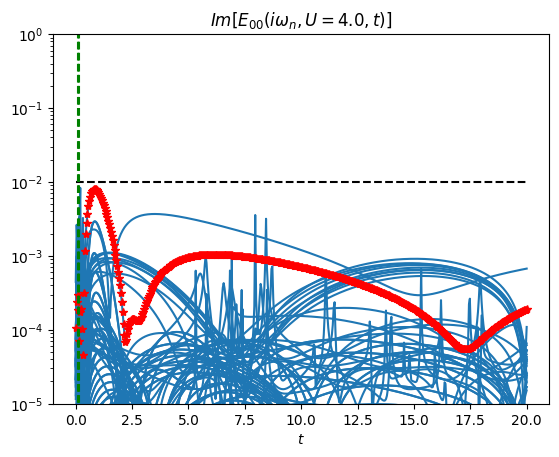

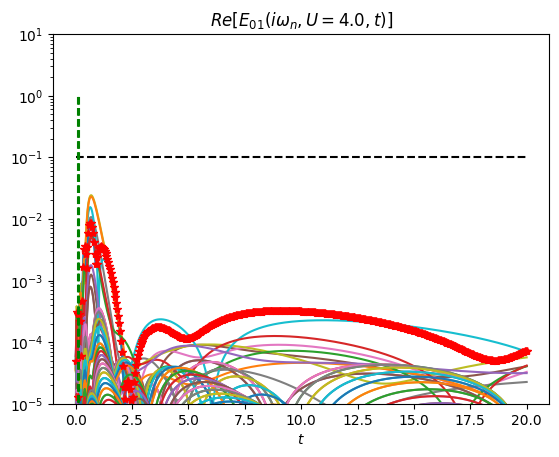

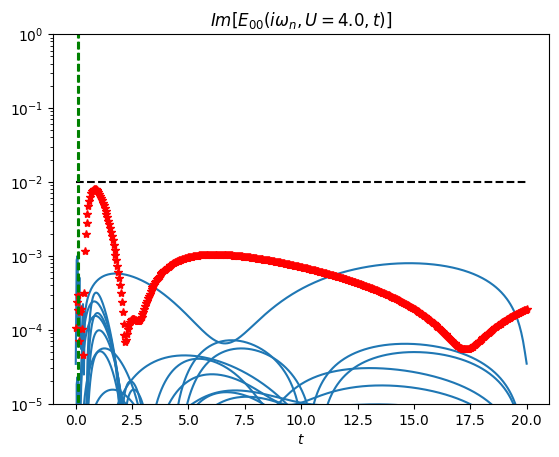

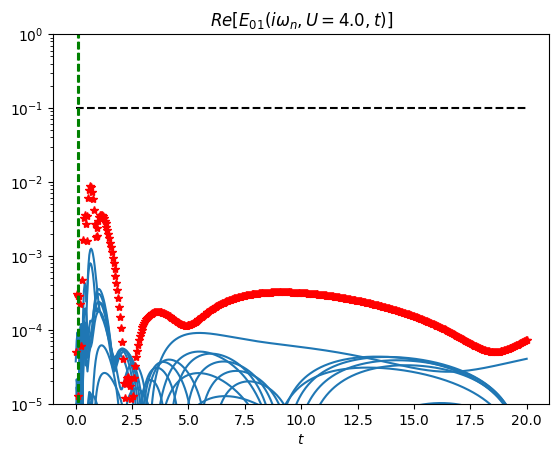

In [15]:
plt.figure(1)
for i in range(wn.size):
    plt.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact_real[:, i, 0,0]-G00_interp[:, i]), 'C0', label = 'AAA')
plt.semilogy(t_values_ED.real, 1e-2+0*t_values_ED.real, 'k--')
plt.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact_real[:, Nw, 0,0]-G00_interp[:, Nw]), 'r*')
plt.semilogy(1/7+0*t_values_ED.real, np.linspace(0,1,t_values_ED.size), 'g--')
plt.semilogy(1/10+0*t_values_ED.real, np.linspace(0,1,t_values_ED.size), 'g--')
plt.ylim([1e-5,1])
plt.xlabel(r"$t$")
plt.title(r'$Im[E_{00}(i\omega_n,U=%.1f, t)]$'%U)

plt.figure(2)
for i in range(wn.size):
    plt.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact_real[:, i, 0,1 ]-G01_interp[:, i]), label = 'AAA')
plt.semilogy(t_values_ED.real, 1e-1+0*t_values_ED.real, 'k--')
plt.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact_real[:, Nw, 0,1 ]-G01_interp[:, Nw]), 'r*', label = 'AAA')
plt.semilogy(1/7+0*t_values_ED.real, np.linspace(0,1,t_values_ED.size), 'g--')
plt.semilogy(1/10+0*t_values_ED.real, np.linspace(0,1,t_values_ED.size), 'g--')
plt.ylim([1e-5, 10])
plt.xlabel(r"$t$")
plt.title(r'$Re[E_{01}(i\omega_n,U=%.1f, t)]$'%U)

plt.figure(3)
for i in wn_id:
    plt.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact_real[:, i, 0,0]-G00_interp[:, i]), 'C0', label = 'AAA')
plt.semilogy(t_values_ED.real, 1e-2+0*t_values_ED.real, 'k--')
plt.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact_real[:, Nw, 0,0]-G00_interp[:, Nw]), 'r*')
plt.semilogy(1/7+0*t_values_ED.real, np.linspace(0,1,t_values_ED.size), 'g--')
plt.semilogy(1/10+0*t_values_ED.real, np.linspace(0,1,t_values_ED.size), 'g--')
plt.ylim([1e-5,1])
plt.xlabel(r"$t$")
plt.title(r'$Im[E_{00}(i\omega_n,U=%.1f, t)]$'%U)

plt.figure(4)
for i in wn_id:
    plt.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact_real[:, i, 0,1 ]-G01_interp[:, i]), 'C0', label = 'AAA')
plt.semilogy(t_values_ED.real, 1e-1+0*t_values_ED.real, 'k--')
plt.semilogy(t_values_ED.real, np.abs(Gij_iwn_exact_real[:, Nw, 0,1 ]-G01_interp[:, Nw]), 'r*', label = 'AAA')
plt.semilogy(1/7+0*t_values_ED.real, np.linspace(0,1,t_values_ED.size), 'g--')
plt.semilogy(1/10+0*t_values_ED.real, np.linspace(0,1,t_values_ED.size), 'g--')
plt.ylim([1e-5, 1])
plt.xlabel(r"$t$")
plt.title(r'$Re[E_{01}(i\omega_n,U=%.1f, t)]$'%U)

In [16]:
print("This runs")
# raise SystemExit
Ed_end = int(Nt/2)
Ed_gap = int(Nt/50)

tau = np.linspace(0,beta,Ntau)
Test_t = t_values_ED[0:Ed_end:Ed_gap]

print('The test ts are: ', Test_t)
G01_iwn_exact_CG = Gij_iwn_exact[0:Ed_end:Ed_gap,:,0,1]
G00_iwn_exact_CG = Gij_iwn_exact[0:Ed_end:Ed_gap,:,0,0]
G01_iwn_interp_CG = G01_interp[0:Ed_end:Ed_gap, :]
G00_iwn_interp_CG = G00_interp[0:Ed_end:Ed_gap, :]

    

Gij_iwn_exact_CG = np.zeros((len(Test_t), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_interp_CG = np.zeros((len(Test_t), wn.size, Ns, Ns), dtype ='complex')

Gij_iwn_interp_CG[:, :, 1, 1] = G00_iwn_interp_CG
Gij_iwn_interp_CG[:, :, 1, 0] = G01_iwn_interp_CG
Gij_iwn_interp_CG[:, :, 0, 0] = G00_iwn_interp_CG
Gij_iwn_interp_CG[:, :, 0, 1] = G01_iwn_interp_CG


Gij_iwn_exact_CG[:, :, 1, 1] = G00_iwn_exact_CG
Gij_iwn_exact_CG[:, :, 1, 0] = G01_iwn_exact_CG
Gij_iwn_exact_CG[:, :, 0, 0] = G00_iwn_exact_CG
Gij_iwn_exact_CG[:, :, 0, 1] = G01_iwn_exact_CG



# Gij_iwn_interp_proj = np.zeros((len(Test_t), wn.size, Ns, Ns), dtype='complex')
# for u in range(len(Test_t)):
#     print("t value is", Test_t[u])
#     func_NN, _, _, _ = anacont(Gij_iwn_interp_CG[u], 1j*wn, tol = 0.1)
#     Gij_iwn_interp_temp = func_NN(1j*wn)
#     Gij_iwn_interp_proj[u] = Gij_iwn_interp_temp



Gij_tau_exact_CG = np.zeros((len(Test_t), Ntau, Ns, Ns))
Gij_tau_interp_CG = np.zeros((len(Test_t), Ntau, Ns, Ns))
Gij_tau_interp_proj = np.zeros((len(Test_t), Ntau, Ns, Ns))

for i in range(len(Test_t)):
    Gij_tau_exact_CG[i] = np.real(ut.Gij_iwn_to_Gij_tau(Gij_iwn_exact_CG[i], wn, tau, beta))
    Gij_tau_interp_CG[i] = np.real(ut.Gij_iwn_to_Gij_tau(Gij_iwn_interp_CG[i], wn, tau, beta))
    # Gij_tau_interp_proj[i] = np.real(ut.Gij_iwn_to_Gij_tau(Gij_iwn_interp_proj[i], wn, tau, beta))





This runs
The test ts are:  [0. +0.j 0.4+0.j 0.8+0.j 1.2+0.j 1.6+0.j 2. +0.j 2.4+0.j 2.8+0.j 3.2+0.j
 3.6+0.j 4. +0.j 4.4+0.j 4.8+0.j 5.2+0.j 5.6+0.j 6. +0.j 6.4+0.j 6.8+0.j
 7.2+0.j 7.6+0.j 8. +0.j 8.4+0.j 8.8+0.j 9.2+0.j 9.6+0.j]


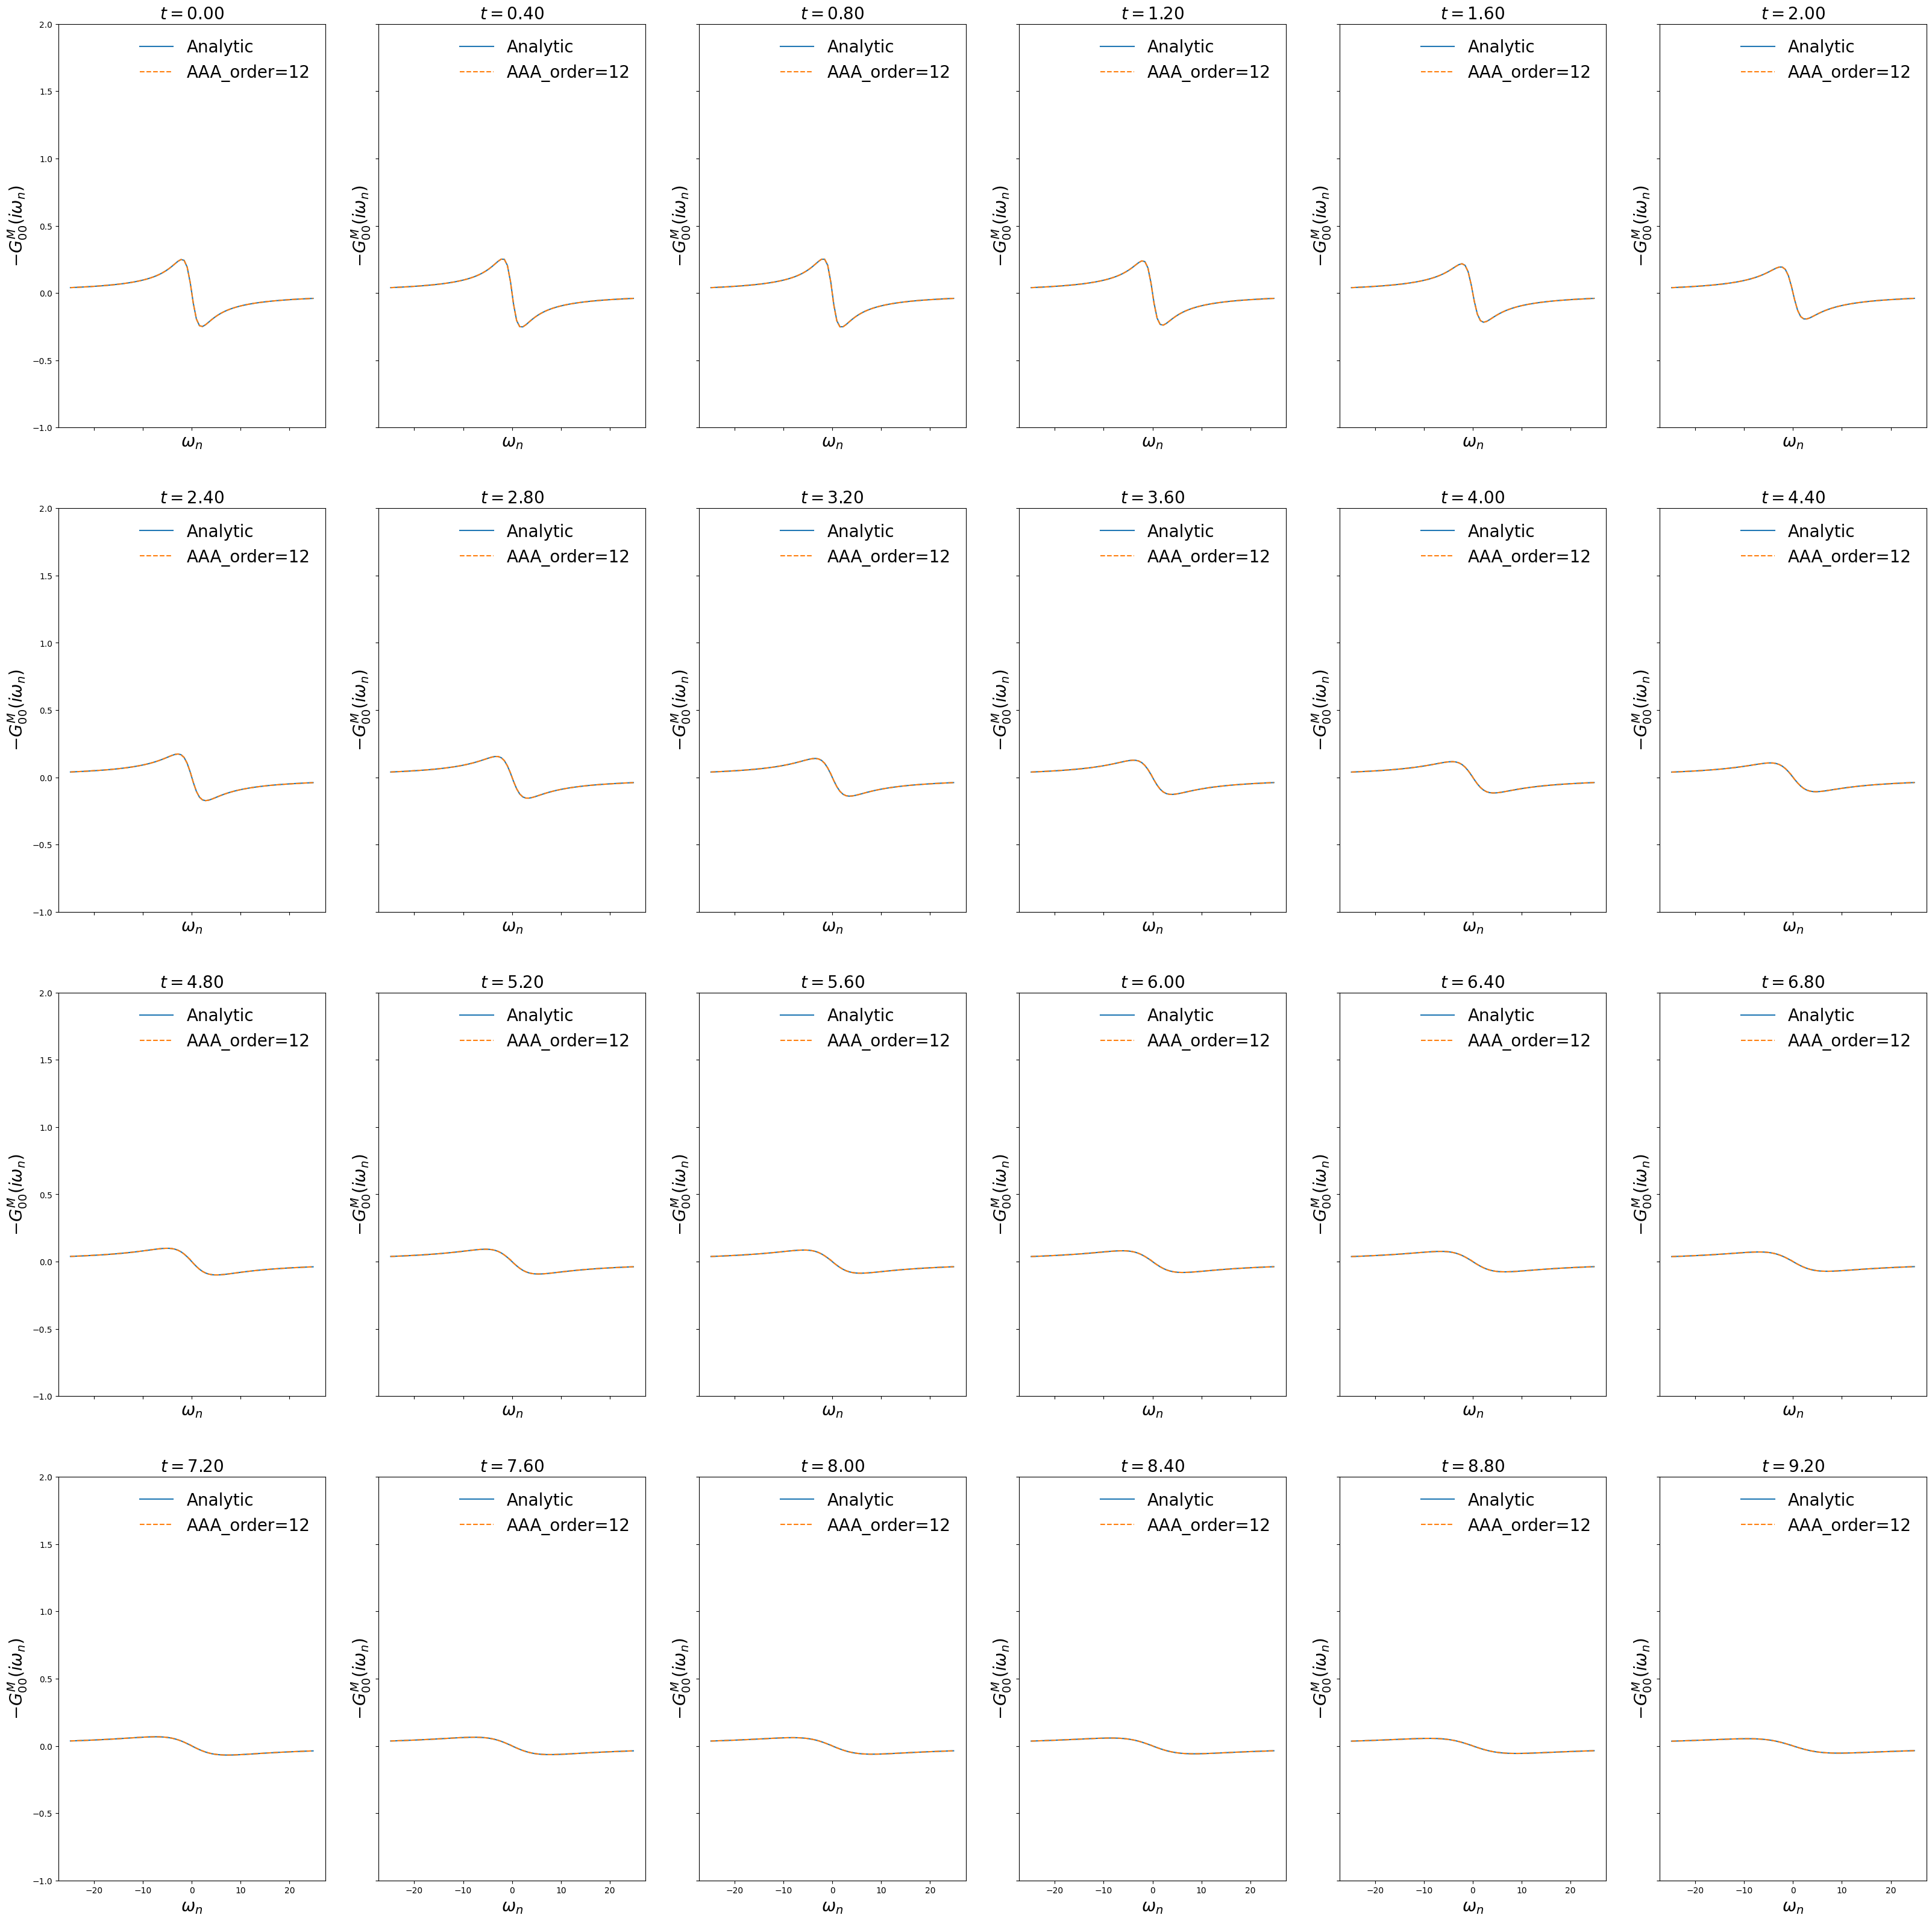

In [17]:
l=0
fig,ax = plt.subplots(4,int(Test_t.size/4),figsize=(40,40),sharex=True,sharey=True)
for i in np.arange(4):
    for j in np.arange(int(Test_t.size/4)):
        ax[i,j].plot(wn, G00_iwn_exact_CG[l,:].imag, label = r'Analytic')
        ax[i,j].plot(wn, G00_iwn_interp_CG[l,:].imag, '--', label = r'AAA_order=%d'%interp_order)
        # ax[i,j].plot(wn, Gij_iwn_interp_proj[l,:, 0, 0].imag, '-.', label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([-1,2])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real), fontsize =20)
        ax[i,j].set_xlabel(r'$\omega_n$', fontsize =20)
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(i\omega_n)$'%(0,0), fontsize =20)
        ax[i,j].legend(frameon= False, fontsize =20)
        l = l+1


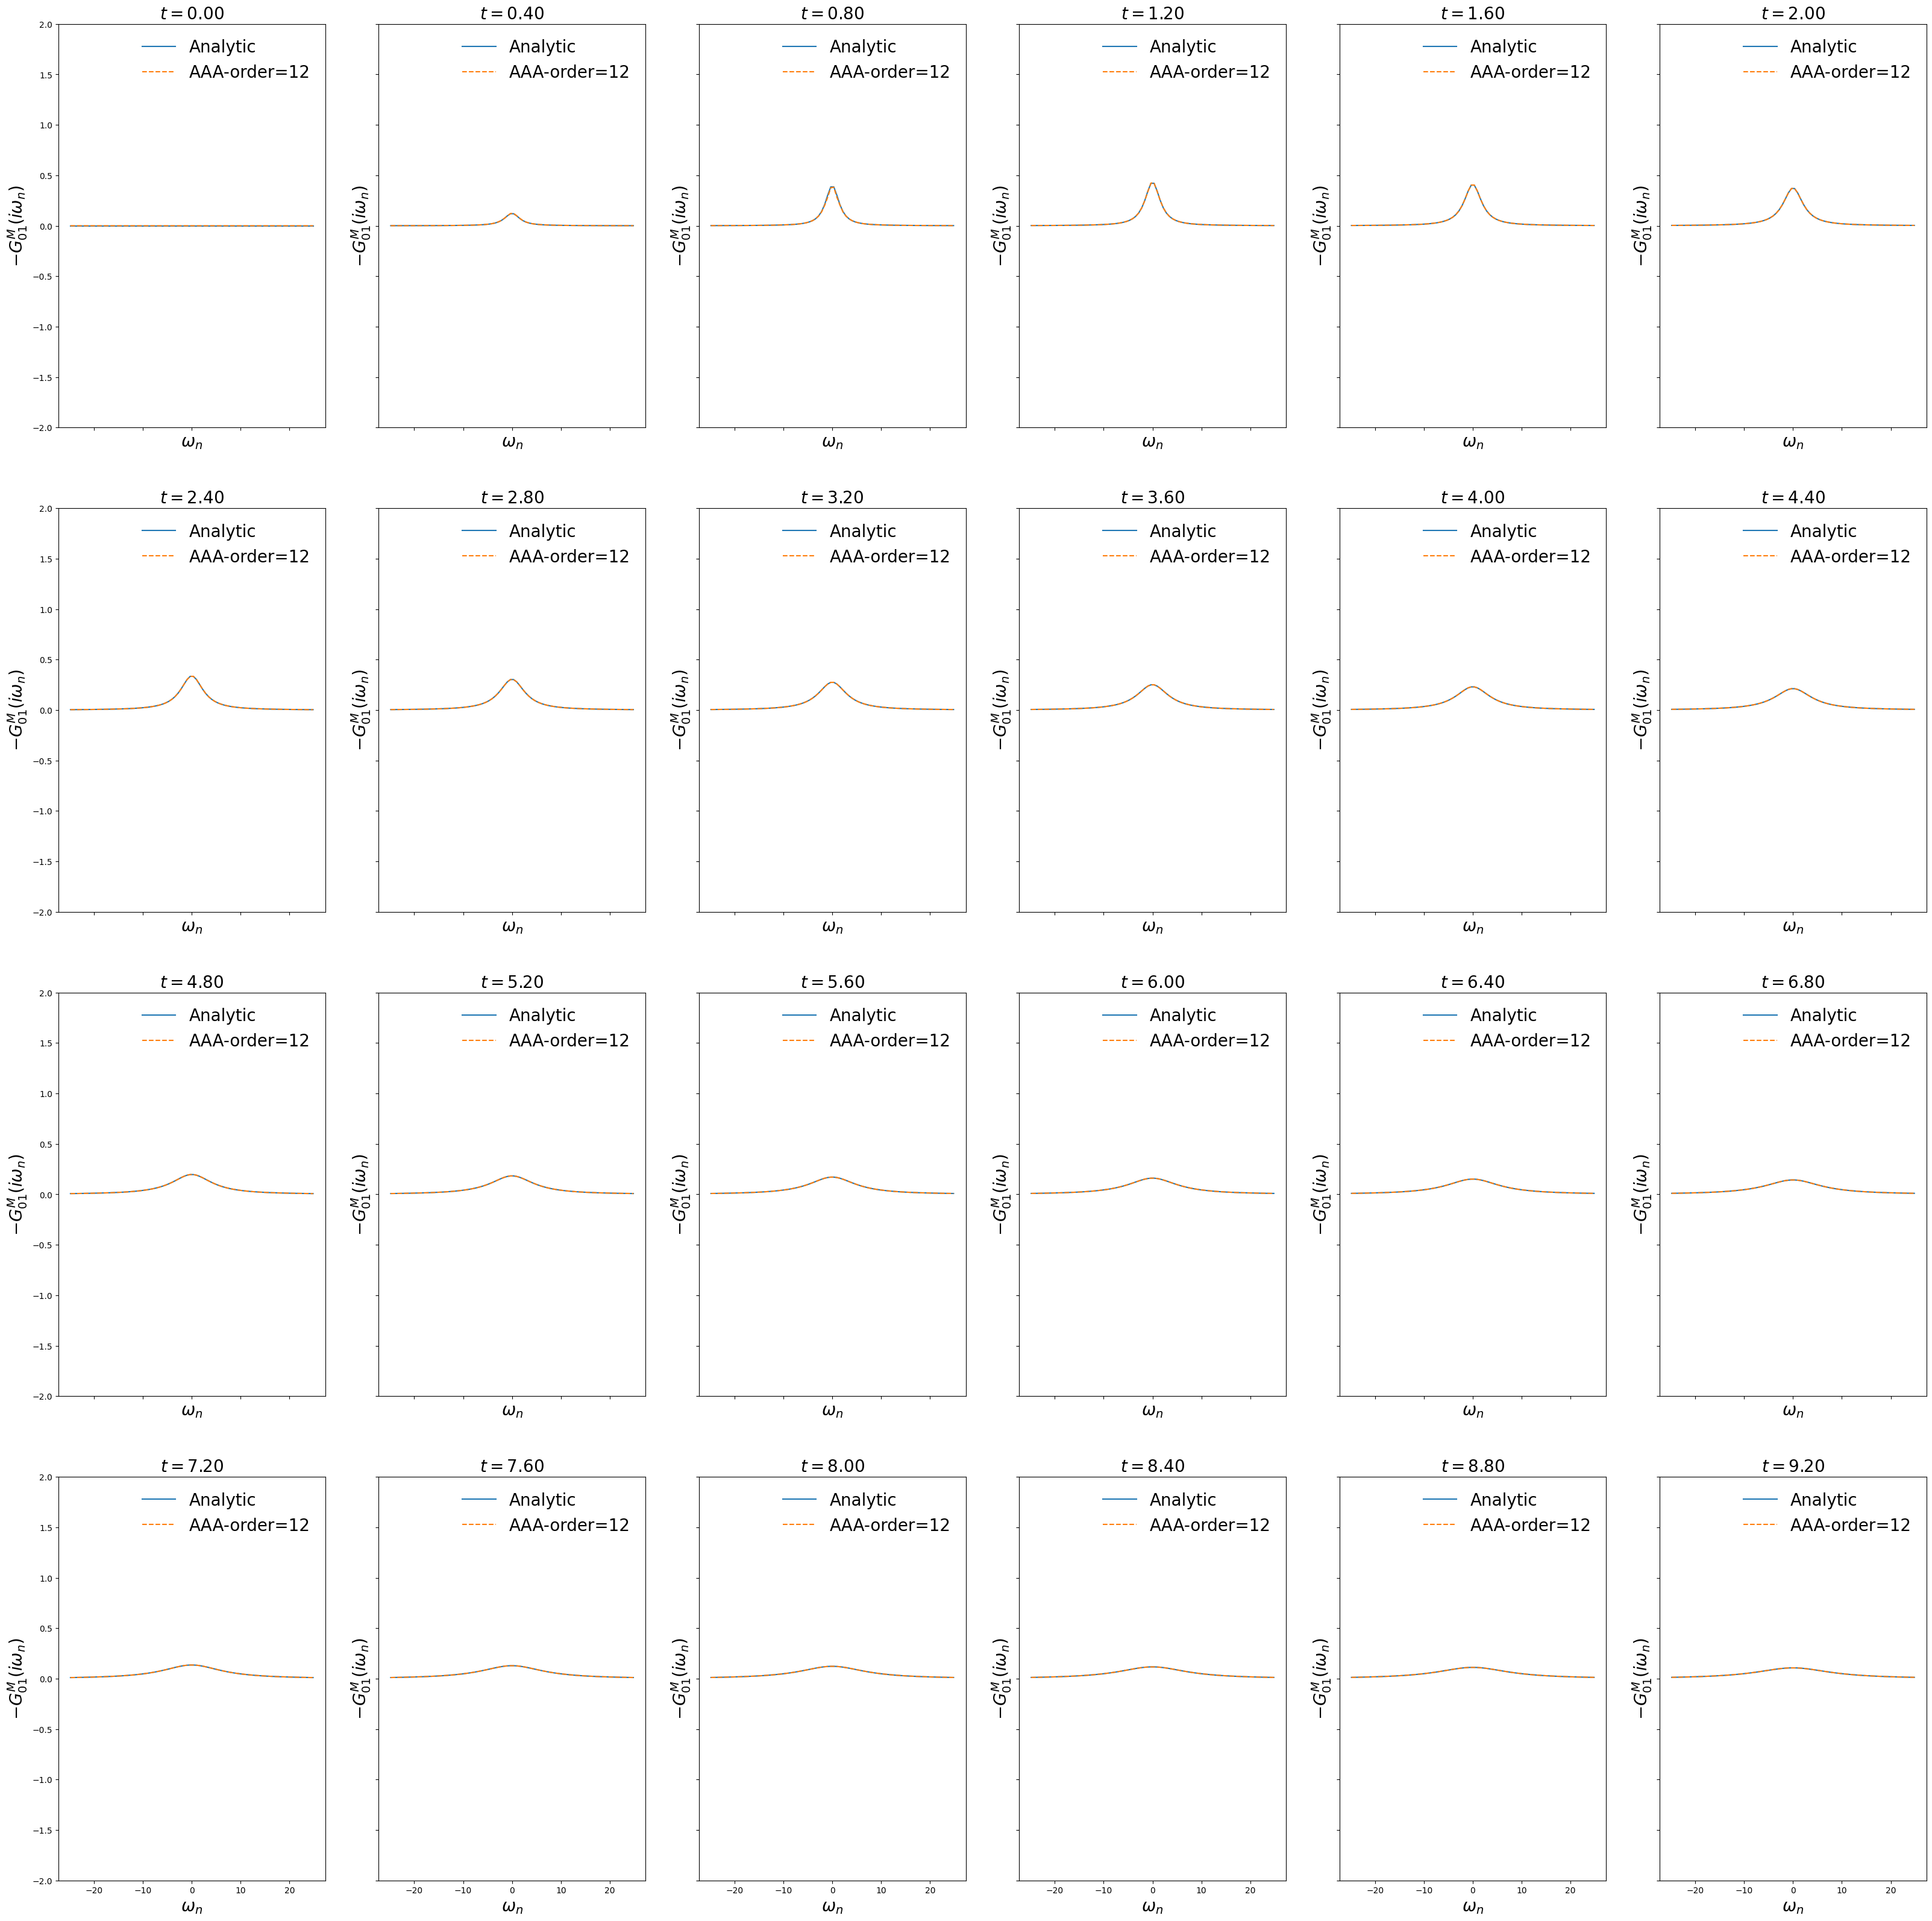

In [18]:
l=0
fig,ax = plt.subplots(4,int(Test_t.size/4),figsize=(40,40),sharex=True,sharey=True)
for i in np.arange(4):
    for j in np.arange(int(Test_t.size/4)):
        ax[i,j].plot(wn, G01_iwn_exact_CG[l,:].real, label = r'Analytic')
        ax[i,j].plot(wn, G01_iwn_interp_CG[l,:].real, '--',  label = r'AAA-order=%d'%interp_order)
        # ax[i,j].plot(wn, Gij_iwn_interp_proj[l,:, 0, 1].real, '-.', label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([-2,2])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real), fontsize =20)
        ax[i,j].set_xlabel(r'$\omega_n$', fontsize =20)
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(i\omega_n)$'%(0,1), fontsize =20)
        ax[i,j].legend(frameon= False, fontsize = 20)
        l = l+1
        

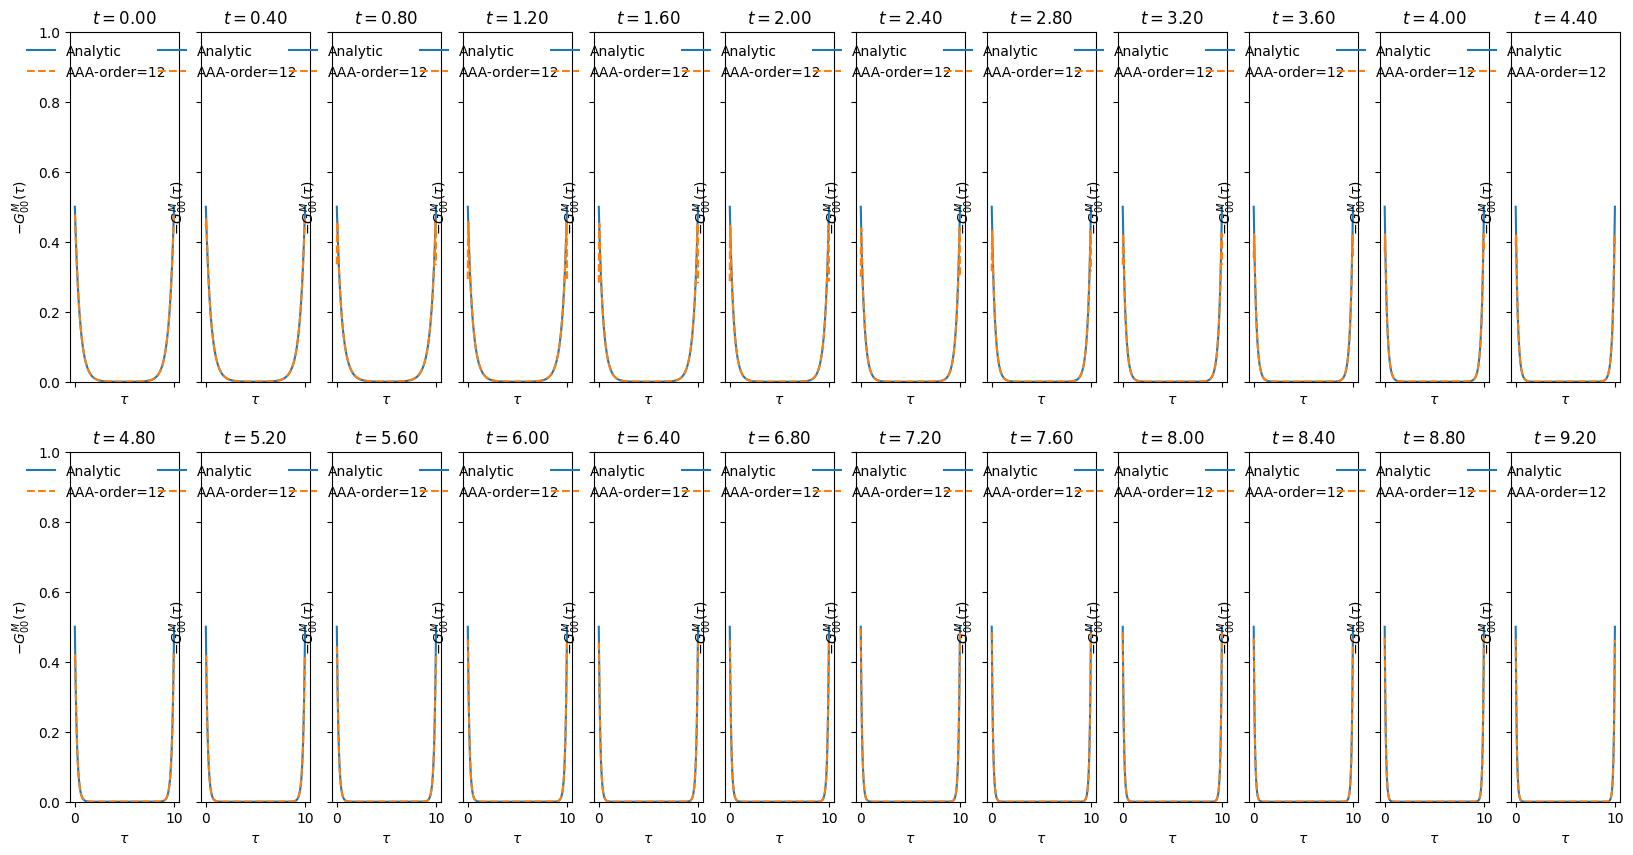

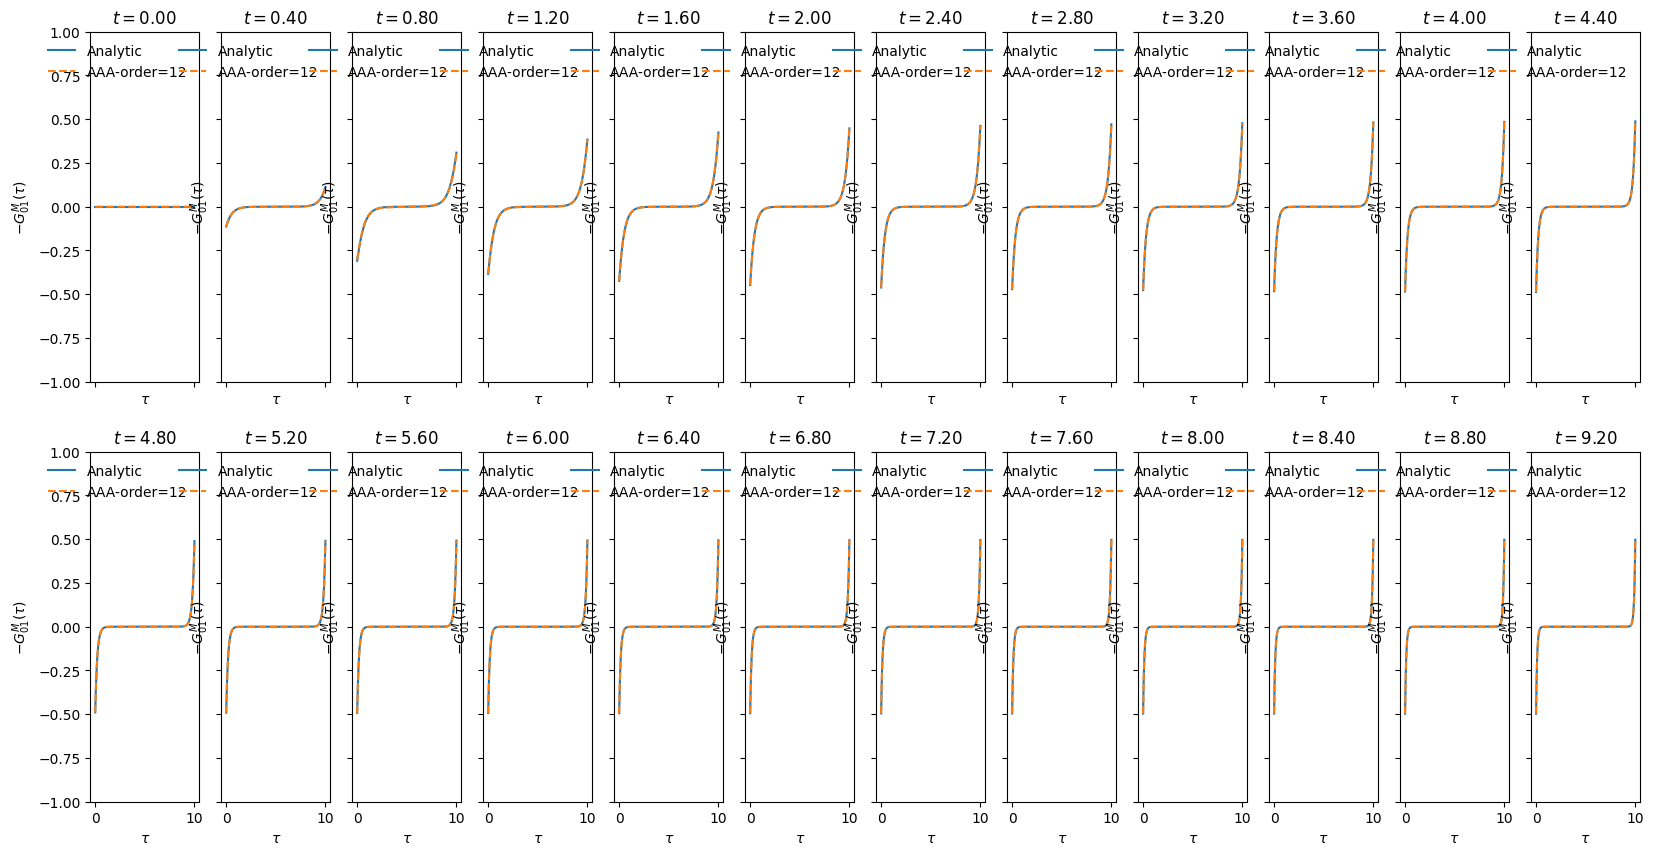

In [19]:
l=0
fig,ax = plt.subplots(2,int(Test_t.size/2),figsize=(20,10),sharex=True,sharey=True)
for i in np.arange(2):
    for j in np.arange(int(Test_t.size/2)):
        ax[i,j].plot(tau, -Gij_tau_exact_CG[l,:, 0, 0], label = r'Analytic')
        ax[i,j].plot(tau, -Gij_tau_interp_CG[l,:, 0, 0], '--', label = r'AAA-order=%d'%interp_order)
        # ax[i,j].plot(tau, -Gij_tau_interp_proj[l,:, 0, 0], '-.', label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([0,1])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real))
        ax[i,j].set_xlabel(r'$\tau$')
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(\tau)$'%(0,0))
        ax[i,j].legend(frameon= False)
        l = l+1
        
l=0
fig,ax = plt.subplots(2,int(Test_t.size/2),figsize=(20,10),sharex=True,sharey=True)
for i in np.arange(2):
    for j in np.arange(int(Test_t.size/2)):
        ax[i,j].plot(tau, -Gij_tau_exact_CG[l,:, 0, 1], label = r'Analytic')
        ax[i,j].plot(tau, -Gij_tau_interp_CG[l,:, 0, 1], '--', label = r'AAA-order=%d'%interp_order)
        # ax[i,j].plot(tau, -Gij_tau_interp_proj[l,:, 0, 1], '-.', label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([-1,1])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real))
        ax[i,j].set_xlabel(r'$\tau$')
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(\tau)$'%(0,1))
        ax[i,j].legend(frameon= False)
        l = l+1



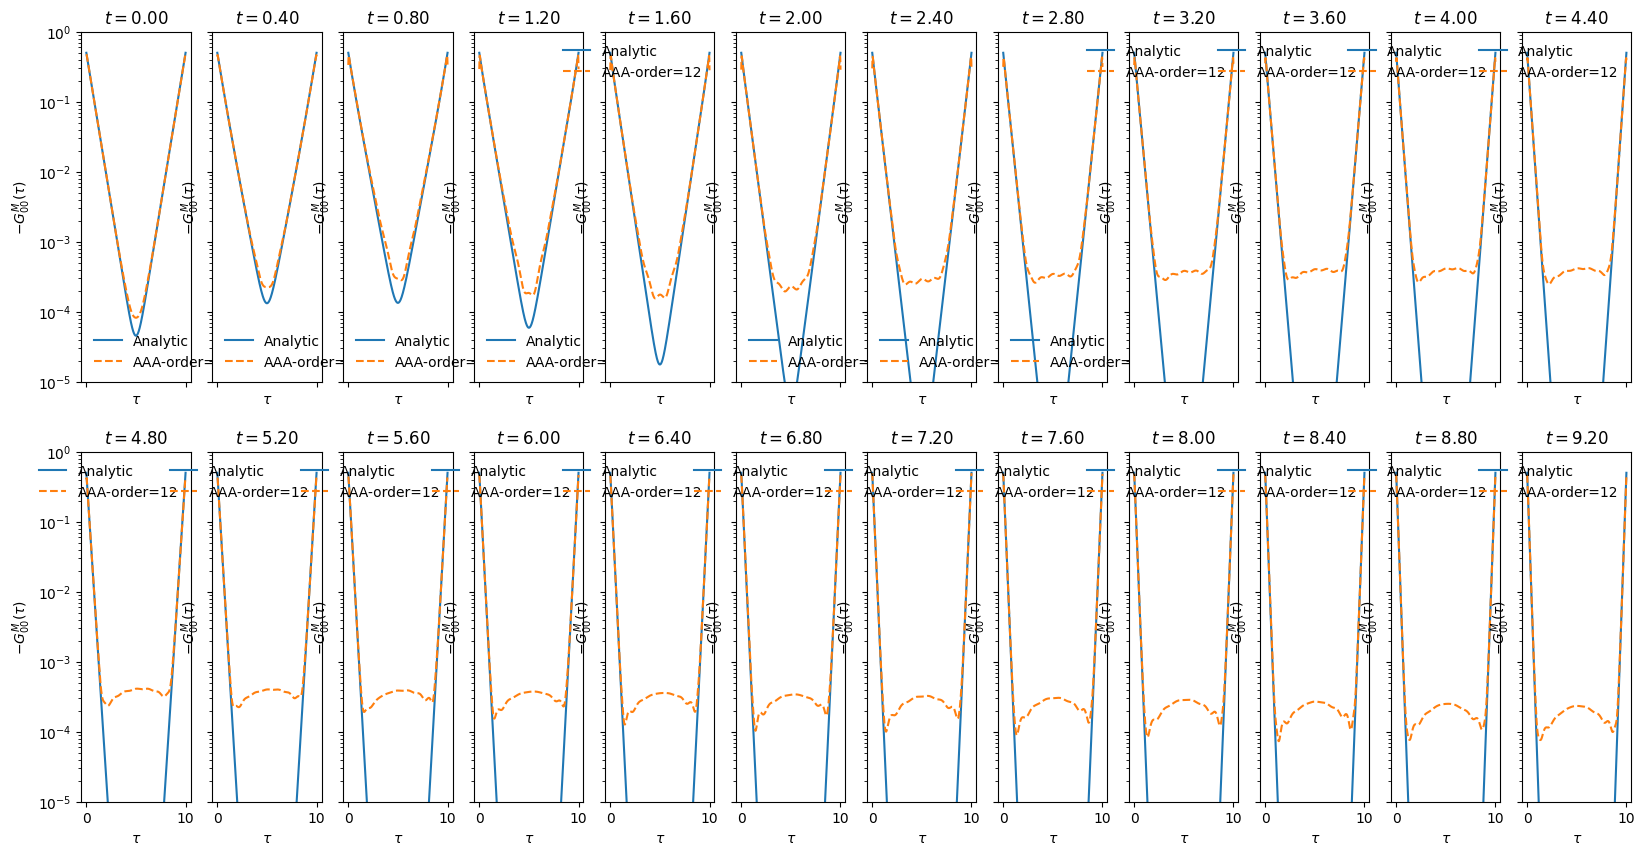

In [20]:
l=0
fig,ax = plt.subplots(2,int(Test_t.size/2),figsize=(20,10),sharex=True,sharey=True)
for i in np.arange(2):
    for j in np.arange(int(Test_t.size/2)):
        ax[i,j].semilogy(tau, -Gij_tau_exact_CG[l,:, 0, 0].real, label = r'Analytic')
        ax[i,j].semilogy(tau, -Gij_tau_interp_CG[l,:, 0, 0], '--', label = r'AAA-order=%d'%interp_order)
        # ax[i,j].semilogy(tau, -Gij_tau_interp_proj[l,:, 0, 0].real, '-.', label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([1e-5, 1])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real))
        ax[i,j].set_xlabel(r'$\tau$')
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(\tau)$'%(0,0))
        ax[i,j].legend(frameon= False)
        l = l+1
        

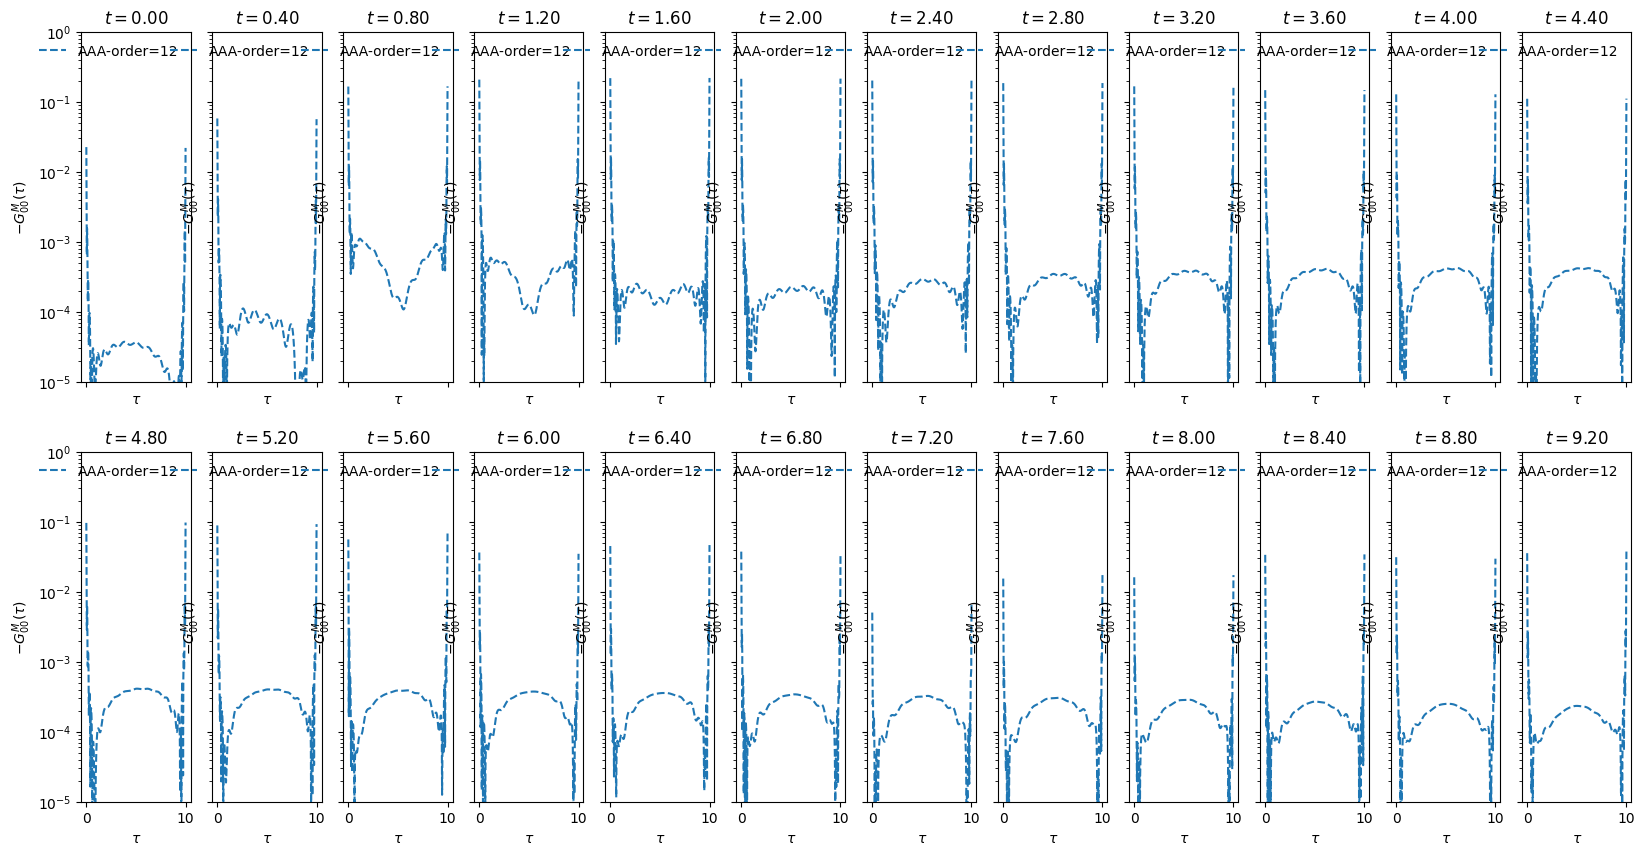

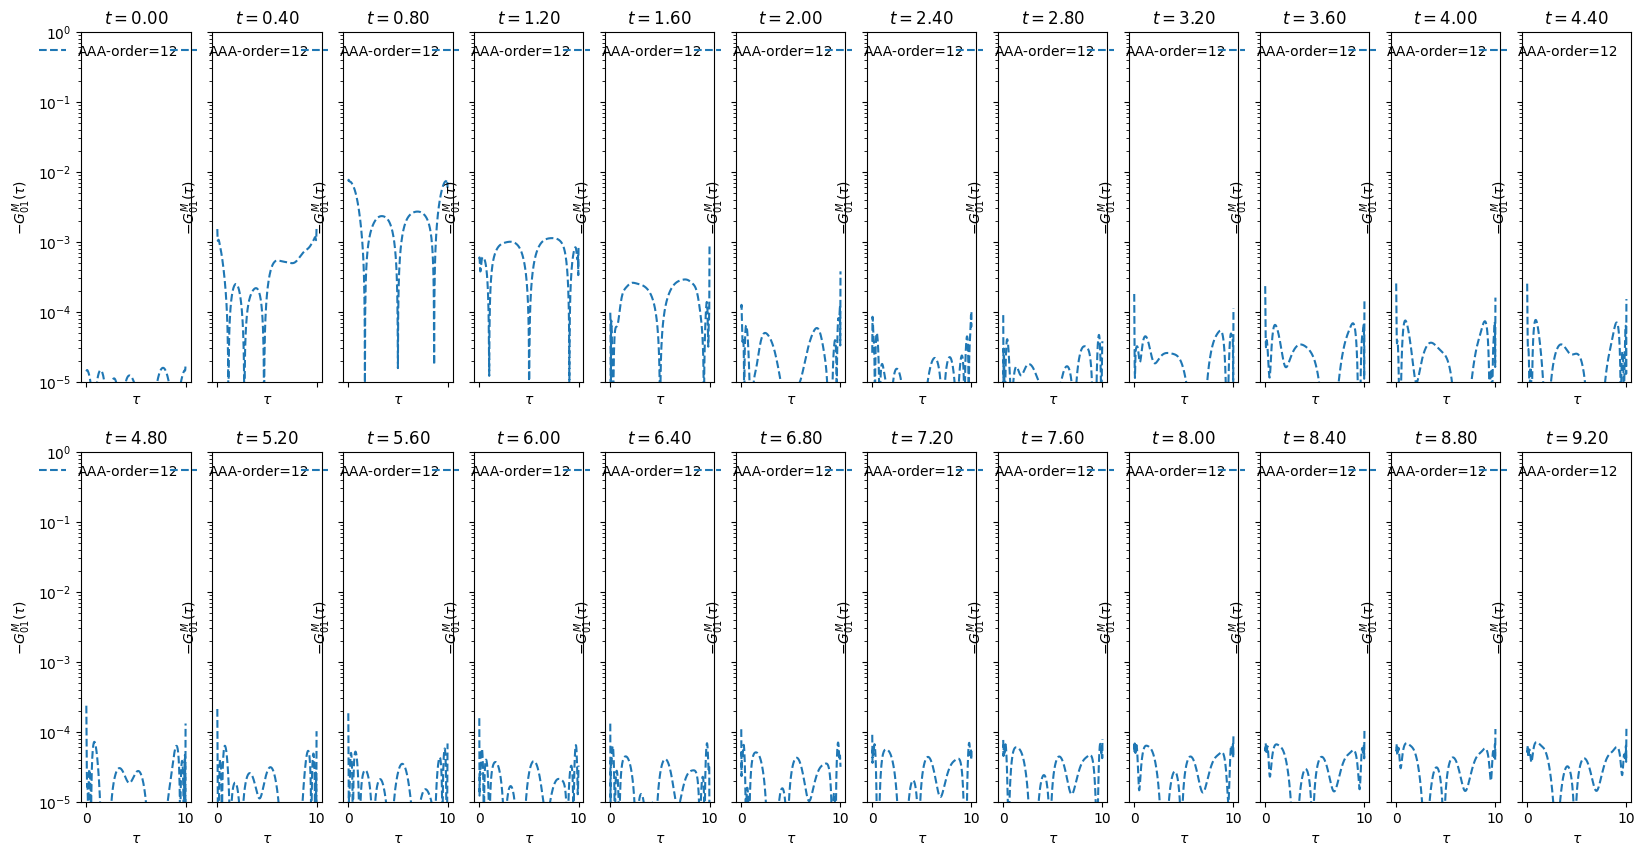

In [21]:
l=0
fig,ax = plt.subplots(2,int(Test_t.size/2),figsize=(20,10),sharex=True,sharey=True)
for i in np.arange(2):
    for j in np.arange(int(Test_t.size/2)):
        # ax[i,j].semilogy(tau, np.abs(Gij_tau_interp_proj[l,:, 0, 0]-Gij_tau_exact_CG[l,:, 0, 0]), label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].semilogy(tau, np.abs(Gij_tau_interp_CG[l,:, 0, 0]-Gij_tau_exact_CG[l,:, 0, 0]), '--', label = r'AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([1e-5, 1])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real))
        ax[i,j].set_xlabel(r'$\tau$')
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(\tau)$'%(0,0))
        ax[i,j].legend(frameon= False)
        l = l+1

l=0
fig,ax = plt.subplots(2,int(Test_t.size/2),figsize=(20,10),sharex=True,sharey=True)
for i in np.arange(2):
    for j in np.arange(int(Test_t.size/2)):
        # ax[i,j].semilogy(tau, np.abs(Gij_tau_interp_proj[l,:, 0, 1]-Gij_tau_exact_CG[l,:, 0, 1]), label = r'Proj, AAA-order=%d'%interp_order)
        ax[i,j].semilogy(tau, np.abs(Gij_tau_interp_CG[l,:, 0, 1]-Gij_tau_exact_CG[l,:, 0, 1]), '--', label = r'AAA-order=%d'%interp_order)
        ax[i,j].set_ylim([1e-5, 1])
        ax[i,j].set_title(r'$t=%.2f$'%(Test_t[l].real))
        ax[i,j].set_xlabel(r'$\tau$')
        ax[i,j].set_ylabel(r'$-G_{%d%d}^M(\tau)$'%(0,1))
        ax[i,j].legend(frameon= False)
        l = l+1